# Setup and Context

### Introduction

On November 27, 1895, Alfred Nobel signed his last will in Paris. When it was opened after his death, the will caused a lot of controversy, as Nobel had left much of his wealth for the establishment of a prize.

Alfred Nobel dictates that his entire remaining estate should be used to endow “prizes to those who, during the preceding year, have conferred the greatest benefit to humankind”.

Every year the Nobel Prize is given to scientists and scholars in the categories chemistry, literature, physics, physiology or medicine, economics, and peace.

<img src=https://i.imgur.com/36pCx5Q.jpg>

Let's see what patterns we can find in the data of the past Nobel laureates. What can we learn about the Nobel prize and our world more generally?

### Upgrade plotly (only Google Colab Notebook)

Google Colab may not be running the latest version of plotly. If you're working in Google Colab, uncomment the line below, run the cell, and restart your notebook server.

In [6]:
%pip install --upgrade plotly

### Import Statements

In [7]:
import pandas as pd # Import pandas for data manipulation and analysis.
import numpy as np # Import numpy for numerical operations, especially array manipulation.
import plotly.express as px # Import plotly.express for easy-to-use, high-level plotting functions.
import seaborn as sns # Import seaborn for statistical data visualization, built on matplotlib.
import matplotlib.pyplot as plt # Import matplotlib.pyplot for creating static, interactive, and animated visualizations.
import matplotlib.dates as mdates # Import matplotlib.dates for handling date and time data in plots.

### Notebook Presentation

In [8]:
# Set pandas display option to format float numbers with two decimal places and comma as thousands separator.
pd.options.display.float_format = '{:,.2f}'.format

### Read the Data

In [9]:
# Read the Nobel Prize data from a CSV file into a pandas DataFrame.
df_data = pd.read_csv('/content/drive/MyDrive/nobel_prize_data.csv')

In [10]:
from google.colab import drive # Import drive module from google.colab to mount Google Drive.
drive.mount('/content/drive') # Mount Google Drive to access files stored there.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Caveats: The exact birth dates for Michael Houghton, Venkatraman Ramakrishnan, and Nadia Murad are unknown. I've substituted them with mid-year estimate of July 2nd.


# Data Exploration & Cleaning

**Challenge**: Preliminary data exploration.
* What is the shape of `df_data`? How many rows and columns?
* What are the column names?
* In which year was the Nobel prize first awarded?
* Which year is the latest year included in the dataset?

In [11]:
# Print the shape of the DataFrame (number of rows, number of columns).
print(df_data.shape)
# Display the first 5 rows of the DataFrame to get a quick overview of the data.
df_data.head(5)

(962, 16)


,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO
0,1901,Chemistry,The Nobel Prize in Chemistry 1901,"""in recognition of the extraordinary services ...",1/1,Individual,Jacobus Henricus van 't Hoff,1852-08-30,Rotterdam,Netherlands,Netherlands,Male,Berlin University,Berlin,Germany,NLD
1,1901,Literature,The Nobel Prize in Literature 1901,"""in special recognition of his poetic composit...",1/1,Individual,Sully Prudhomme,1839-03-16,Paris,France,France,Male,NaN,NaN,NaN,FRA
2,1901,Medicine,The Nobel Prize in Physiology or Medicine 1901,"""for his work on serum therapy, especially its...",1/1,Individual,Emil Adolf von Behring,1854-03-15,Hansdorf (Lawice),Prussia (Poland),Poland,Male,Marburg University,Marburg,Germany,POL
3,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,Individual,Frédéric Passy,1822-05-20,Paris,France,France,Male,NaN,NaN,NaN,FRA
4,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,Individual,Jean Henry Dunant,1828-05-08,Geneva,Switzerland,Switzerland,Male,NaN,NaN,NaN,CHE


In [12]:
# Display concise summary of the DataFrame, including data types and non-null values.
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   year                   962 non-null    int64 
 1   category               962 non-null    object
 2   prize                  962 non-null    object
 3   motivation             874 non-null    object
 4   prize_share            962 non-null    object
 5   laureate_type          962 non-null    object
 6   full_name              962 non-null    object
 7   birth_date             934 non-null    object
 8   birth_city             931 non-null    object
 9   birth_country          934 non-null    object
 10  birth_country_current  934 non-null    object
 11  sex                    934 non-null    object
 12  organization_name      707 non-null    object
 13  organization_city      707 non-null    object
 14  organization_country   708 non-null    object
 15  ISO                    

In [13]:
# Locate and display the row corresponding to the minimum 'year' in the DataFrame, representing the first Nobel Prize awarded.
df_data.loc[df_data.year.idxmin()]

,0
year,1901
category,Chemistry
prize,The Nobel Prize in Chemistry 1901
motivation,"""in recognition of the extraordinary services ..."
prize_share,1/1
laureate_type,Individual
full_name,Jacobus Henricus van 't Hoff
birth_date,1852-08-30
birth_city,Rotterdam
birth_country,Netherlands


In [14]:
print("2020 was the latest year included in the dataset")
# Generate descriptive statistics of the DataFrame, including count, mean, std, min, max, and quartiles.
df_data.describe()

2020 was the latest year included in the dataset


,year
count,962.00
mean,"1,971.82"
std,33.81
min,"1,901.00"
25%,"1,948.00"
50%,"1,977.00"
75%,"2,001.00"
max,"2,020.00"


**Challange**:
* Are there any duplicate values in the dataset?
* Are there NaN values in the dataset?
* Which columns tend to have NaN values?
* How many NaN values are there per column?
* Why do these columns have NaN values?  

### Check for Duplicates

In [15]:
# Check if there are any duplicate rows in the DataFrame. .any() returns True if any duplicates are found, .sum() counts them.
df_data.duplicated().any().sum()

np.int64(0)

### Check for NaN Values

In [16]:
# Check if any column contains NaN (Not a Number) values. .any() returns True for columns with NaNs, .sum() counts such columns.
df_data.isna().any().sum()

np.int64(10)

In [17]:
# Show a boolean Series indicating for each column if it contains any NaN values.
df_data.isna().any()

,0
year,False
category,False
prize,False
motivation,True
prize_share,False
laureate_type,False
full_name,False
birth_date,True
birth_city,True
birth_country,True


In [18]:
# Calculate and display the total number of NaN values for each column in the DataFrame.
df_data.isna().sum()

,0
year,0
category,0
prize,0
motivation,88
prize_share,0
laureate_type,0
full_name,0
birth_date,28
birth_city,31
birth_country,28


**Outcome**: Why are there so many NaN values for the birth date? And why are there so many missing values among the organisation columns?

Filtering on the NaN values in the birth date column we see that we get back a bunch of organisations, like the UN or the Red Cross.

In [19]:
# Define a subset of columns to display.
col_subset = ['year','category', 'laureate_type',
              'birth_date','full_name', 'organization_name']
# Filter the DataFrame to show rows where 'birth_date' is NaN and display the specified columns.
df_data.loc[df_data.birth_date.isna()][col_subset]

,year,category,laureate_type,birth_date,full_name,organization_name
24,1904,Peace,Organization,NaN,Institut de droit international (Institute of ...,NaN
60,1910,Peace,Organization,NaN,Bureau international permanent de la Paix (Per...,NaN
89,1917,Peace,Organization,NaN,Comité international de la Croix Rouge (Intern...,NaN
200,1938,Peace,Organization,NaN,Office international Nansen pour les Réfugiés ...,NaN
215,1944,Peace,Organization,NaN,Comité international de la Croix Rouge (Intern...,NaN
237,1947,Peace,Organization,NaN,American Friends Service Committee (The Quakers),NaN
238,1947,Peace,Organization,NaN,Friends Service Council (The Quakers),NaN
283,1954,Peace,Organization,NaN,Office of the United Nations High Commissioner...,NaN
348,1963,Peace,Organization,NaN,Comité international de la Croix Rouge (Intern...,NaN
349,1963,Peace,Organization,NaN,Ligue des Sociétés de la Croix-Rouge (League o...,NaN


**Outcome**: That makes sense. We also see that since the organisation's name is in the full_name column, the organisation_name column contains NaN.




In [20]:
# Define a subset of columns to display.
col_subset = ['year','category', 'laureate_type','full_name', 'organization_name']
# Filter the DataFrame to show rows where 'organization_name' is NaN and display the specified columns.
df_data.loc[df_data.organization_name.isna()][col_subset]

,year,category,laureate_type,full_name,organization_name
1,1901,Literature,Individual,Sully Prudhomme,NaN
3,1901,Peace,Individual,Frédéric Passy,NaN
4,1901,Peace,Individual,Jean Henry Dunant,NaN
7,1902,Literature,Individual,Christian Matthias Theodor Mommsen,NaN
9,1902,Peace,Individual,Charles Albert Gobat,NaN
...,...,...,...,...,...
932,2018,Peace,Individual,Nadia Murad,NaN
942,2019,Literature,Individual,Peter Handke,NaN
946,2019,Peace,Individual,Abiy Ahmed Ali,NaN
954,2020,Literature,Individual,Louise Glück,NaN


**Outcome**: In addition, when we look at for rows where the organization_name column has no value, we also see that many prizes went to people who were not affiliated with a university or research institute. This includes many of the Literature and Peace prize winners.

### Type Conversions

**Challenge**:
* Convert the `birth_date` column to Pandas `Datetime` objects
* Add a Column called `share_pct` which has the laureates' share as a percentage in the form of a floating-point number.

#### Convert Year and Birth Date to Datetime

In [21]:
# Convert the 'birth_date' column to datetime objects for proper date manipulation.
df_data.birth_date = pd.to_datetime(df_data['birth_date'])

# Display the DataFrame information again to confirm the data type change.
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   year                   962 non-null    int64         
 1   category               962 non-null    object        
 2   prize                  962 non-null    object        
 3   motivation             874 non-null    object        
 4   prize_share            962 non-null    object        
 5   laureate_type          962 non-null    object        
 6   full_name              962 non-null    object        
 7   birth_date             934 non-null    datetime64[ns]
 8   birth_city             931 non-null    object        
 9   birth_country          934 non-null    object        
 10  birth_country_current  934 non-null    object        
 11  sex                    934 non-null    object        
 12  organization_name      707 non-null    object        
 13  organ

#### Add a Column with the Prize Share as a Percentage

In [22]:
# Clean the 'prize_share' column: replace '1/' with an empty string and convert to integer.
price_share_col = df_data.prize_share.replace({"1/":""}, regex=True).astype(int)

# Calculate the percentage share of the prize. For example, '1/2' becomes 50%.
share_pct_col  = round(((1 / price_share_col) * 100),2)
# Insert the new 'share_pct' column into the DataFrame at position 5.
df_data.insert(5, 'share_pct', share_pct_col)

# Display the first 7 rows of the DataFrame to show the newly added 'share_pct' column.
df_data.head(7)

,year,category,prize,motivation,prize_share,share_pct,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO
0,1901,Chemistry,The Nobel Prize in Chemistry 1901,"""in recognition of the extraordinary services ...",1/1,100.00,Individual,Jacobus Henricus van 't Hoff,1852-08-30,Rotterdam,Netherlands,Netherlands,Male,Berlin University,Berlin,Germany,NLD
1,1901,Literature,The Nobel Prize in Literature 1901,"""in special recognition of his poetic composit...",1/1,100.00,Individual,Sully Prudhomme,1839-03-16,Paris,France,France,Male,NaN,NaN,NaN,FRA
2,1901,Medicine,The Nobel Prize in Physiology or Medicine 1901,"""for his work on serum therapy, especially its...",1/1,100.00,Individual,Emil Adolf von Behring,1854-03-15,Hansdorf (Lawice),Prussia (Poland),Poland,Male,Marburg University,Marburg,Germany,POL
3,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,50.00,Individual,Frédéric Passy,1822-05-20,Paris,France,France,Male,NaN,NaN,NaN,FRA
4,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,50.00,Individual,Jean Henry Dunant,1828-05-08,Geneva,Switzerland,Switzerland,Male,NaN,NaN,NaN,CHE
5,1901,Physics,The Nobel Prize in Physics 1901,"""in recognition of the extraordinary services ...",1/1,100.00,Individual,Wilhelm Conrad Röntgen,1845-03-27,Lennep (Remscheid),Prussia (Germany),Germany,Male,Munich University,Munich,Germany,DEU
6,1902,Chemistry,The Nobel Prize in Chemistry 1902,"""in recognition of the extraordinary services ...",1/1,100.00,Individual,Hermann Emil Fischer,1852-10-09,Euskirchen,Prussia (Germany),Germany,Male,Berlin University,Berlin,Germany,DEU


In [23]:
# Display concise summary of the DataFrame, including data types and non-null values, to verify the new column.
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   year                   962 non-null    int64         
 1   category               962 non-null    object        
 2   prize                  962 non-null    object        
 3   motivation             874 non-null    object        
 4   prize_share            962 non-null    object        
 5   share_pct              962 non-null    float64       
 6   laureate_type          962 non-null    object        
 7   full_name              962 non-null    object        
 8   birth_date             934 non-null    datetime64[ns]
 9   birth_city             931 non-null    object        
 10  birth_country          934 non-null    object        
 11  birth_country_current  934 non-null    object        
 12  sex                    934 non-null    object        
 13  organ

# Plotly Donut Chart: Percentage of Male vs. Female Laureates

**Challenge**: Create a [donut chart using plotly](https://plotly.com/python/pie-charts/) which shows how many prizes went to men compared to how many prizes went to women. What percentage of all the prizes went to women?

In [24]:
# Count the occurrences of each unique value in the 'sex' column.
sex_count = df_data.sex.value_counts()
sex_count

,count
sex,
Male,876
Female,58


In [25]:
# Create a pie chart to visualize the distribution of Nobel Prize winners by sex.
# Labels are taken from the index (Male, Female) of sex_count, values from sex_count.values.
# A hole of 0.6 makes it a donut chart.
fig = px.pie(labels=sex_count.index, values=sex_count.values, title="Percentage of Male vs. Female Nobel Price Winner", names=sex_count.index,hole=0.6)
# Update trace to show percentage inside the slices and set font size.
fig.update_traces(textposition='inside', textfont_size=15, textinfo='percent')
fig.show()

# Who were the first 3 Women to Win the Nobel Prize?

**Challenge**:
* What are the names of the first 3 female Nobel laureates?
* What did the win the prize for?
* What do you see in their `birth_country`? Were they part of an organisation?

In [26]:
# Filter the DataFrame to get the first 3 female Nobel laureates.
first_3_womens_NB =  df_data[df_data.sex == 'Female'].head(3)

In [27]:
# Define a list of columns to look up for the first 3 female Nobel laureates.
lookup_col = ['year','full_name', 'motivation', 'birth_country', 'organization_name']
# Display the selected columns for the first 3 female Nobel laureates.
first_3_womens_NB[lookup_col]

,year,full_name,motivation,birth_country,organization_name
18,1903,"Marie Curie, née Sklodowska","""in recognition of the extraordinary services ...",Russian Empire (Poland),NaN
29,1905,"Baroness Bertha Sophie Felicita von Suttner, n...",NaN,Austrian Empire (Czech Republic),NaN
51,1909,Selma Ottilia Lovisa Lagerlöf,"""in appreciation of the lofty idealism, vivid ...",Sweden,NaN


**Outcome**: Even without looking at the data, you might have already guessed one of the famous names: Marie Curie.



# Find the Repeat Winners

**Challenge**: Did some people get a Nobel Prize more than once? If so, who were they?

In [28]:
print("Total of 4 Individual won the nobel price more than 1 and 2 institution won nobel price more than 1")
# Count the occurrences of each full name and get the top 7 to identify repeat winners.
repeated_winner = df_data.full_name.value_counts().head(7)

repeated_winner.head(7)

Total of 4 Individual won the nobel price more than 1 and 2 institution won nobel price more than 1


,count
full_name,
Comité international de la Croix Rouge (International Committee of the Red Cross),3
Frederick Sanger,2
John Bardeen,2
Linus Carl Pauling,2
Office of the United Nations High Commissioner for Refugees (UNHCR),2
"Marie Curie, née Sklodowska",2
John C. Harsanyi,1


**Outcome**: We see that Marie Curie, Linus Carl Pauling actually got the Nobel prize twice. Also, the International Red Cross was awarded the Peace prize a total of 3 times. The first two times were both during the devastating World Wars.

# Number of Prizes per Category

**Challenge**:
* In how many categories are prizes awarded?
* Create a plotly bar chart with the number of prizes awarded by category.
* Use the color scale called `Aggrnyl` to colour the chart, but don't show a color axis.
* Which category has the most number of prizes awarded?
* Which category has the fewest number of prizes awarded?

In [29]:
# Print the unique categories of Nobel Prizes awarded.
print(f" total of 6 categories nobel peace prizes are awarded which are: {df_data.category.unique()}")

 total of 6 categories nobel peace prizes are awarded which are: ['Chemistry' 'Literature' 'Medicine' 'Peace' 'Physics' 'Economics']


In [30]:
# Count the number of prizes awarded in each category.
awarded_category_count = df_data.category.value_counts()

# Create a bar chart showing the number of prizes awarded per category.
# The 'color' parameter uses the count of prizes for coloring with a 'Aggrnyl' sequential scale.
fig = px.bar(x=awarded_category_count.index, y=awarded_category_count.values, title="number of prizes awarded by category", color_continuous_scale='Aggrnyl', color = awarded_category_count.values)
# Customize layout: set x and y axis titles and hide the color scale.
fig.update_layout(xaxis_title='Nobel Prize Category',
                    coloraxis_showscale=False,
                    yaxis_title='Number of Prizes')
fig.show()

In [31]:
# Print statements summarizing which category has the most and fewest awards based on the chart.
print(f"As we can see in the chart medicine is the category where most of the award being awarded the total number of awards are 222")
print(f"As we can see in the chart Economics is the category where least of the award being awarded the total number of awards are 86 only")

As we can see in the chart medicine is the category where most of the award being awarded the total number of awards are 222
As we can see in the chart Economics is the category where least of the award being awarded the total number of awards are 86 only


**Challenge**:
* When was the first prize in the field of Economics awarded?
* Who did the prize go to?

In [32]:
# Filter the DataFrame to show only entries for the 'Economics' category and display the first row.
df_data[df_data.category == 'Economics'].head(1)

,year,category,prize,motivation,prize_share,share_pct,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO
393,1969,Economics,The Sveriges Riksbank Prize in Economic Scienc...,"""for having developed and applied dynamic mode...",1/2,50.00,Individual,Jan Tinbergen,1903-04-12,the Hague,Netherlands,Netherlands,Male,The Netherlands School of Economics,Rotterdam,Netherlands,NLD


In [33]:
# Print a statement indicating the year the first Economics Nobel Prize was awarded.
print(f"The first prize in the field of Economics awarded in year of 1969")

The first prize in the field of Economics awarded in year of 1969


In [34]:
# Print a statement indicating the name of the first Economics Nobel Prize.
print(f"The first prize in the field of Economics awarded in the category of The 'Sveriges Riksbank Prize in Economic Science'.")

The first prize in the field of Economics awarded in the category of The 'Sveriges Riksbank Prize in Economic Science'.


# Male and Female Winners by Category

**Challenge**: Create a [plotly bar chart](https://plotly.com/python/bar-charts/) that shows the split between men and women by category.
* Hover over the bar chart. How many prizes went to women in Literature compared to Physics?

<img src=https://i.imgur.com/od8TfOp.png width=650>

In [35]:
# Group data by 'category' and 'sex' and count the number of prizes for each group.
cat_men_women = df_data.groupby(['category', 'sex'],
                               as_index=False).agg({'prize': pd.Series.count})
# Sort the results by the number of prizes in descending order.
cat_men_women.sort_values('prize', ascending=False, inplace=True)

In [36]:
# Create a grouped bar chart using Plotly Express to show prizes awarded per category, split by sex.
v_bar_split = px.bar(x = cat_men_women.category,
                     y = cat_men_women.prize,
                     color = cat_men_women.sex, # Use 'sex' column to differentiate colors for men and women
                     title='Number of Prizes Awarded per Category split by Men and Women')

# Update the layout for better readability, setting x and y axis titles.
v_bar_split.update_layout(xaxis_title='Nobel Prize Category',
                          yaxis_title='Number of Prizes')
# The next line shows the plot. It's separated for clarity.
# v_bar_split.show()

In [37]:
# Display the Plotly bar chart showing the split between men and women by category.
v_bar_split.show()

**Outcome**: We see that overall the imbalance is pretty large with physics, economics, and chemistry. Women are somewhat more represented in categories of Medicine, Literature and Peace. Splitting bar charts like this is an incredibly powerful way to show a more granular picture.





# Number of Prizes Awarded Over Time

**Challenge**: Are more prizes awarded recently than when the prize was first created? Show the trend in awards visually.
* Count the number of prizes awarded every year.
* Create a 5 year rolling average of the number of prizes (Hint: see previous lessons analysing Google Trends).
* Using Matplotlib superimpose the rolling average on a scatter plot.
* Show a tick mark on the x-axis for every 5 years from 1900 to 2020. (Hint: you'll need to use NumPy).

<img src=https://i.imgur.com/4jqYuWC.png width=650>

* Use the [named colours](https://matplotlib.org/3.1.0/gallery/color/named_colors.html) to draw the data points in `dogerblue` while the rolling average is coloured in `crimson`.

<img src=https://i.imgur.com/u3RlcJn.png width=350>

* Looking at the chart, did the first and second world wars have an impact on the number of prizes being given out?
* What could be the reason for the trend in the chart?


In [38]:
# Group the DataFrame by 'year' and count the number of prizes awarded each year.
prize_per_year = df_data.groupby('year').size()

# Display the first 5 entries of the yearly prize count.
prize_per_year.head(5)

,0
year,
1901,6
1902,7
1903,7
1904,6
1905,5


In [39]:
# Calculate the 5-year rolling average of the number of prizes awarded per year.
moving_average = prize_per_year.rolling(window=5).mean()

# Display the first few entries of the rolling average.
moving_average.head()

,0
year,
1901,NaN
1902,NaN
1903,NaN
1904,NaN
1905,6.20


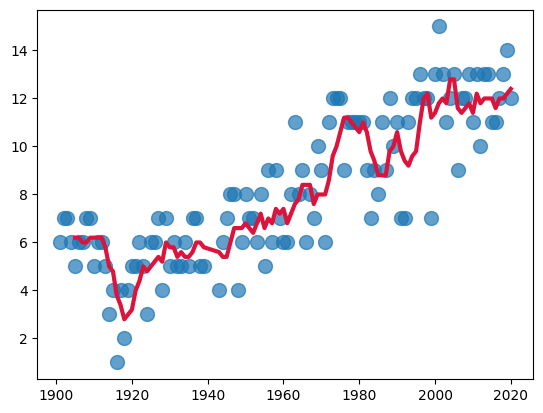

In [40]:
# Create a scatter plot of prizes per year with a rolling average line.
# Scatter plot for individual years (prize_per_year.index, prize_per_year.values).
plt.scatter(x = prize_per_year.index, y = prize_per_year.values, alpha=0.7, s=100)
# Line plot for the 5-year moving average, colored crimson and thicker.
plt.plot(prize_per_year.index, moving_average.values, c='crimson', linewidth=3)

# Displays chart explicitly
plt.show()

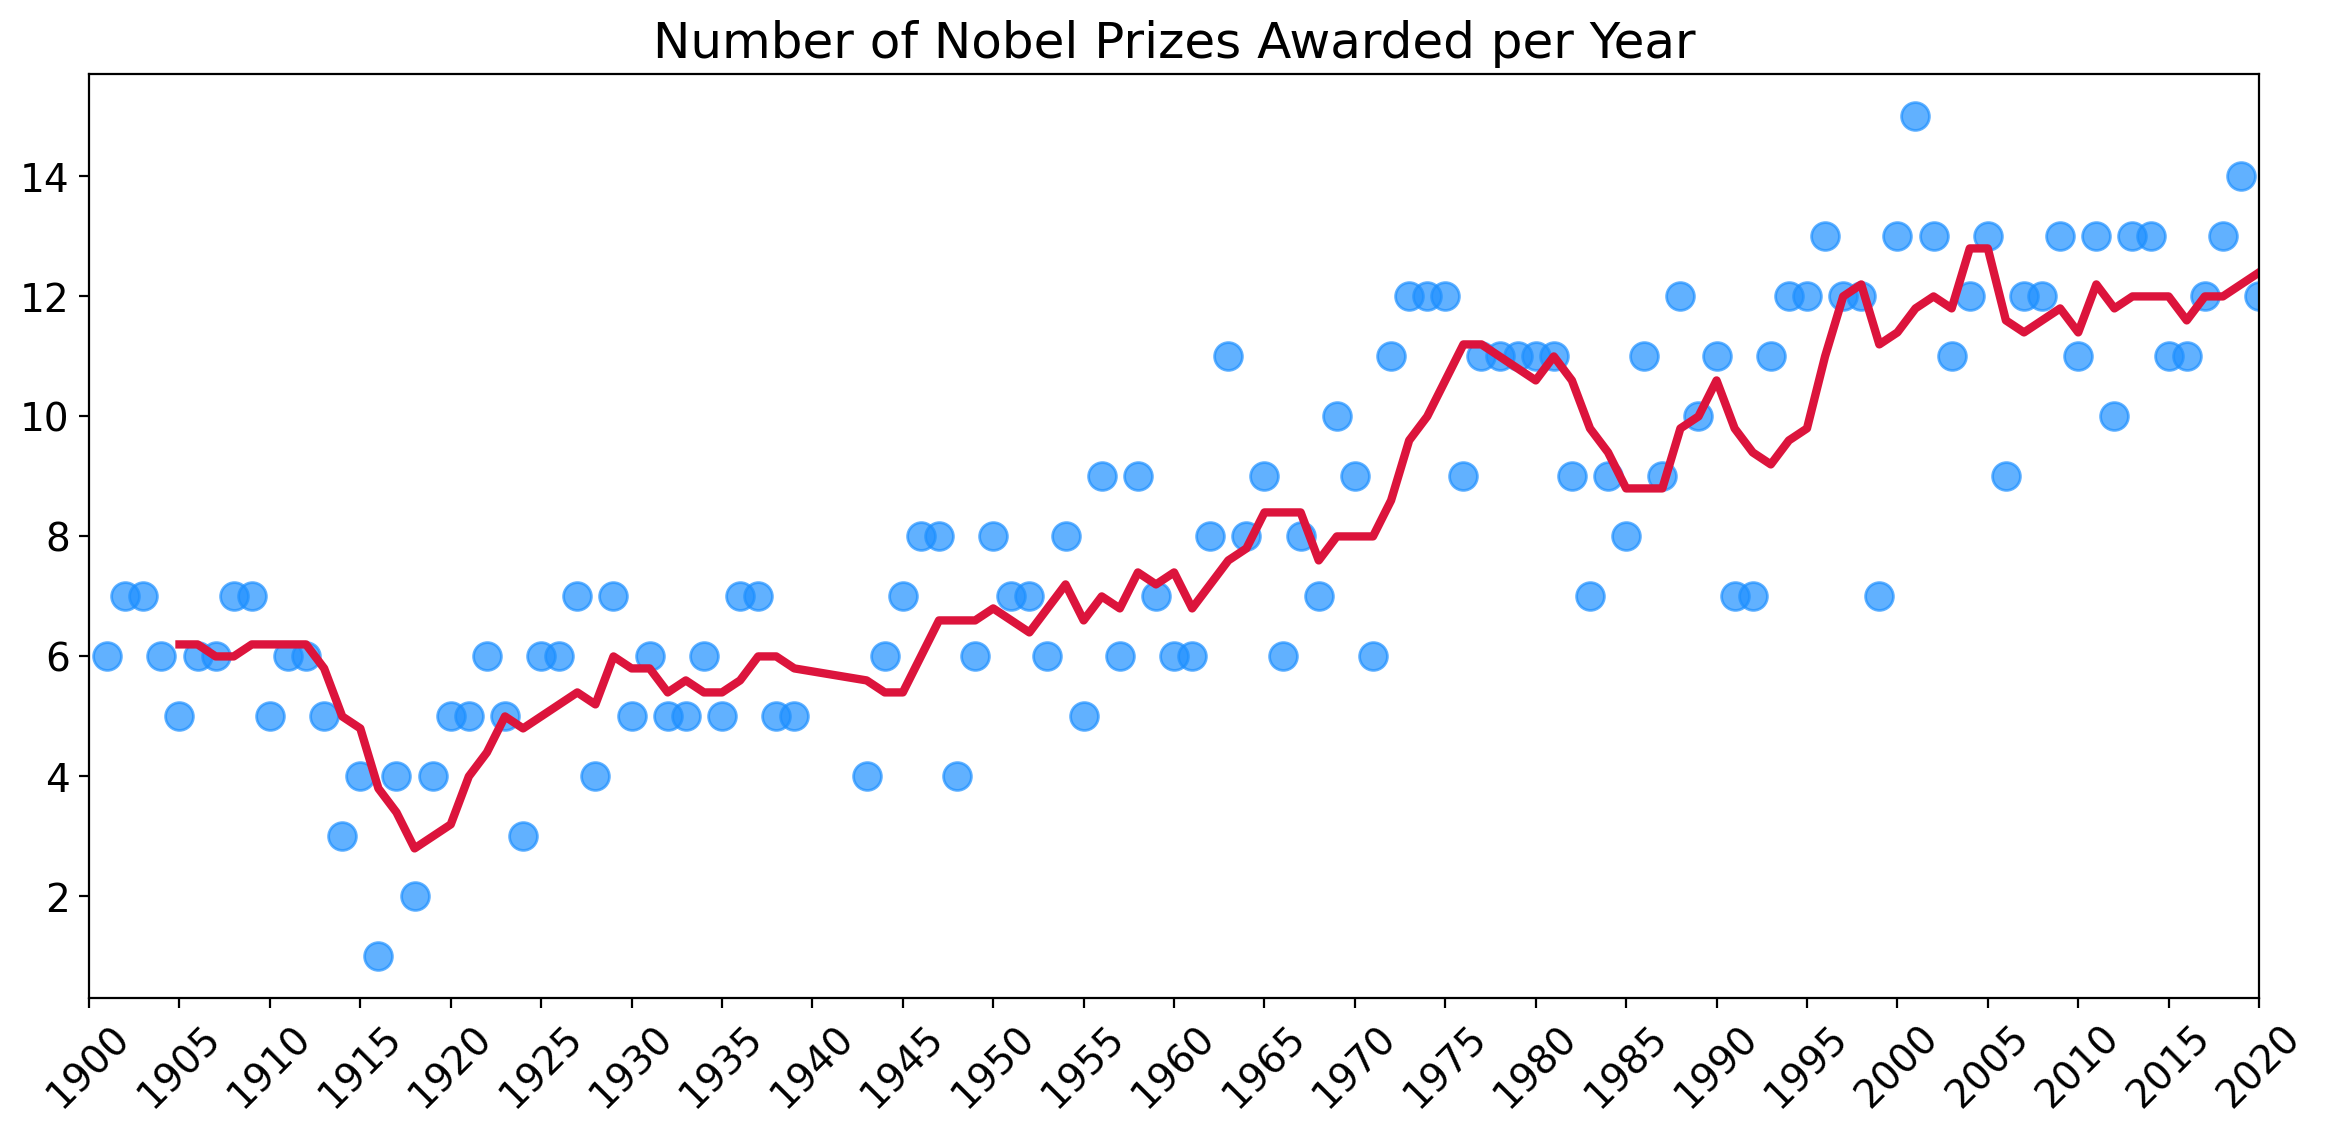

In [41]:
plt.figure(figsize=(14,6), dpi=200) # Set figure size and resolution
plt.title('Number of Nobel Prizes Awarded per Year', fontsize=18) # Set plot title
plt.yticks(fontsize=14) # Set y-axis tick font size
# Set x-axis ticks to every 5 years from 1900 to 2020, with labels rotated
plt.xticks(ticks=np.arange(1900, 2021, step=5),
           fontsize=14,
           rotation=45)

ax = plt.gca() # Get the current axes object
ax.set_xlim(1900, 2020) # Set x-axis limits

# Scatter plot of prizes per year, colored dodgerblue with transparency
ax.scatter(x=prize_per_year.index,
           y=prize_per_year.values,
           c='dodgerblue',
           alpha=0.7,
           s=100,)

# Line plot of the 5-year moving average, colored crimson and thicker
ax.plot(moving_average.index,
        moving_average.values,
        c='crimson',
        linewidth=3,)

plt.show()

# Are More Prizes Shared Than Before?

**Challenge**: Investigate if more prizes are shared than before.

* Calculate the average prize share of the winners on a year by year basis.
* Calculate the 5 year rolling average of the percentage share.
* Copy-paste the cell from the chart you created above.
* Modify the code to add a secondary axis to your Matplotlib chart.
* Plot the rolling average of the prize share on this chart.
* See if you can invert the secondary y-axis to make the relationship even more clear.

In [42]:
# Calculate the yearly average prize share of the winners.
yearly_avg_share = df_data.groupby(by='year').agg({'share_pct': pd.Series.mean})
# Calculate the 5-year rolling average of the percentage share.
share_moving_average = yearly_avg_share.rolling(window=5).mean()

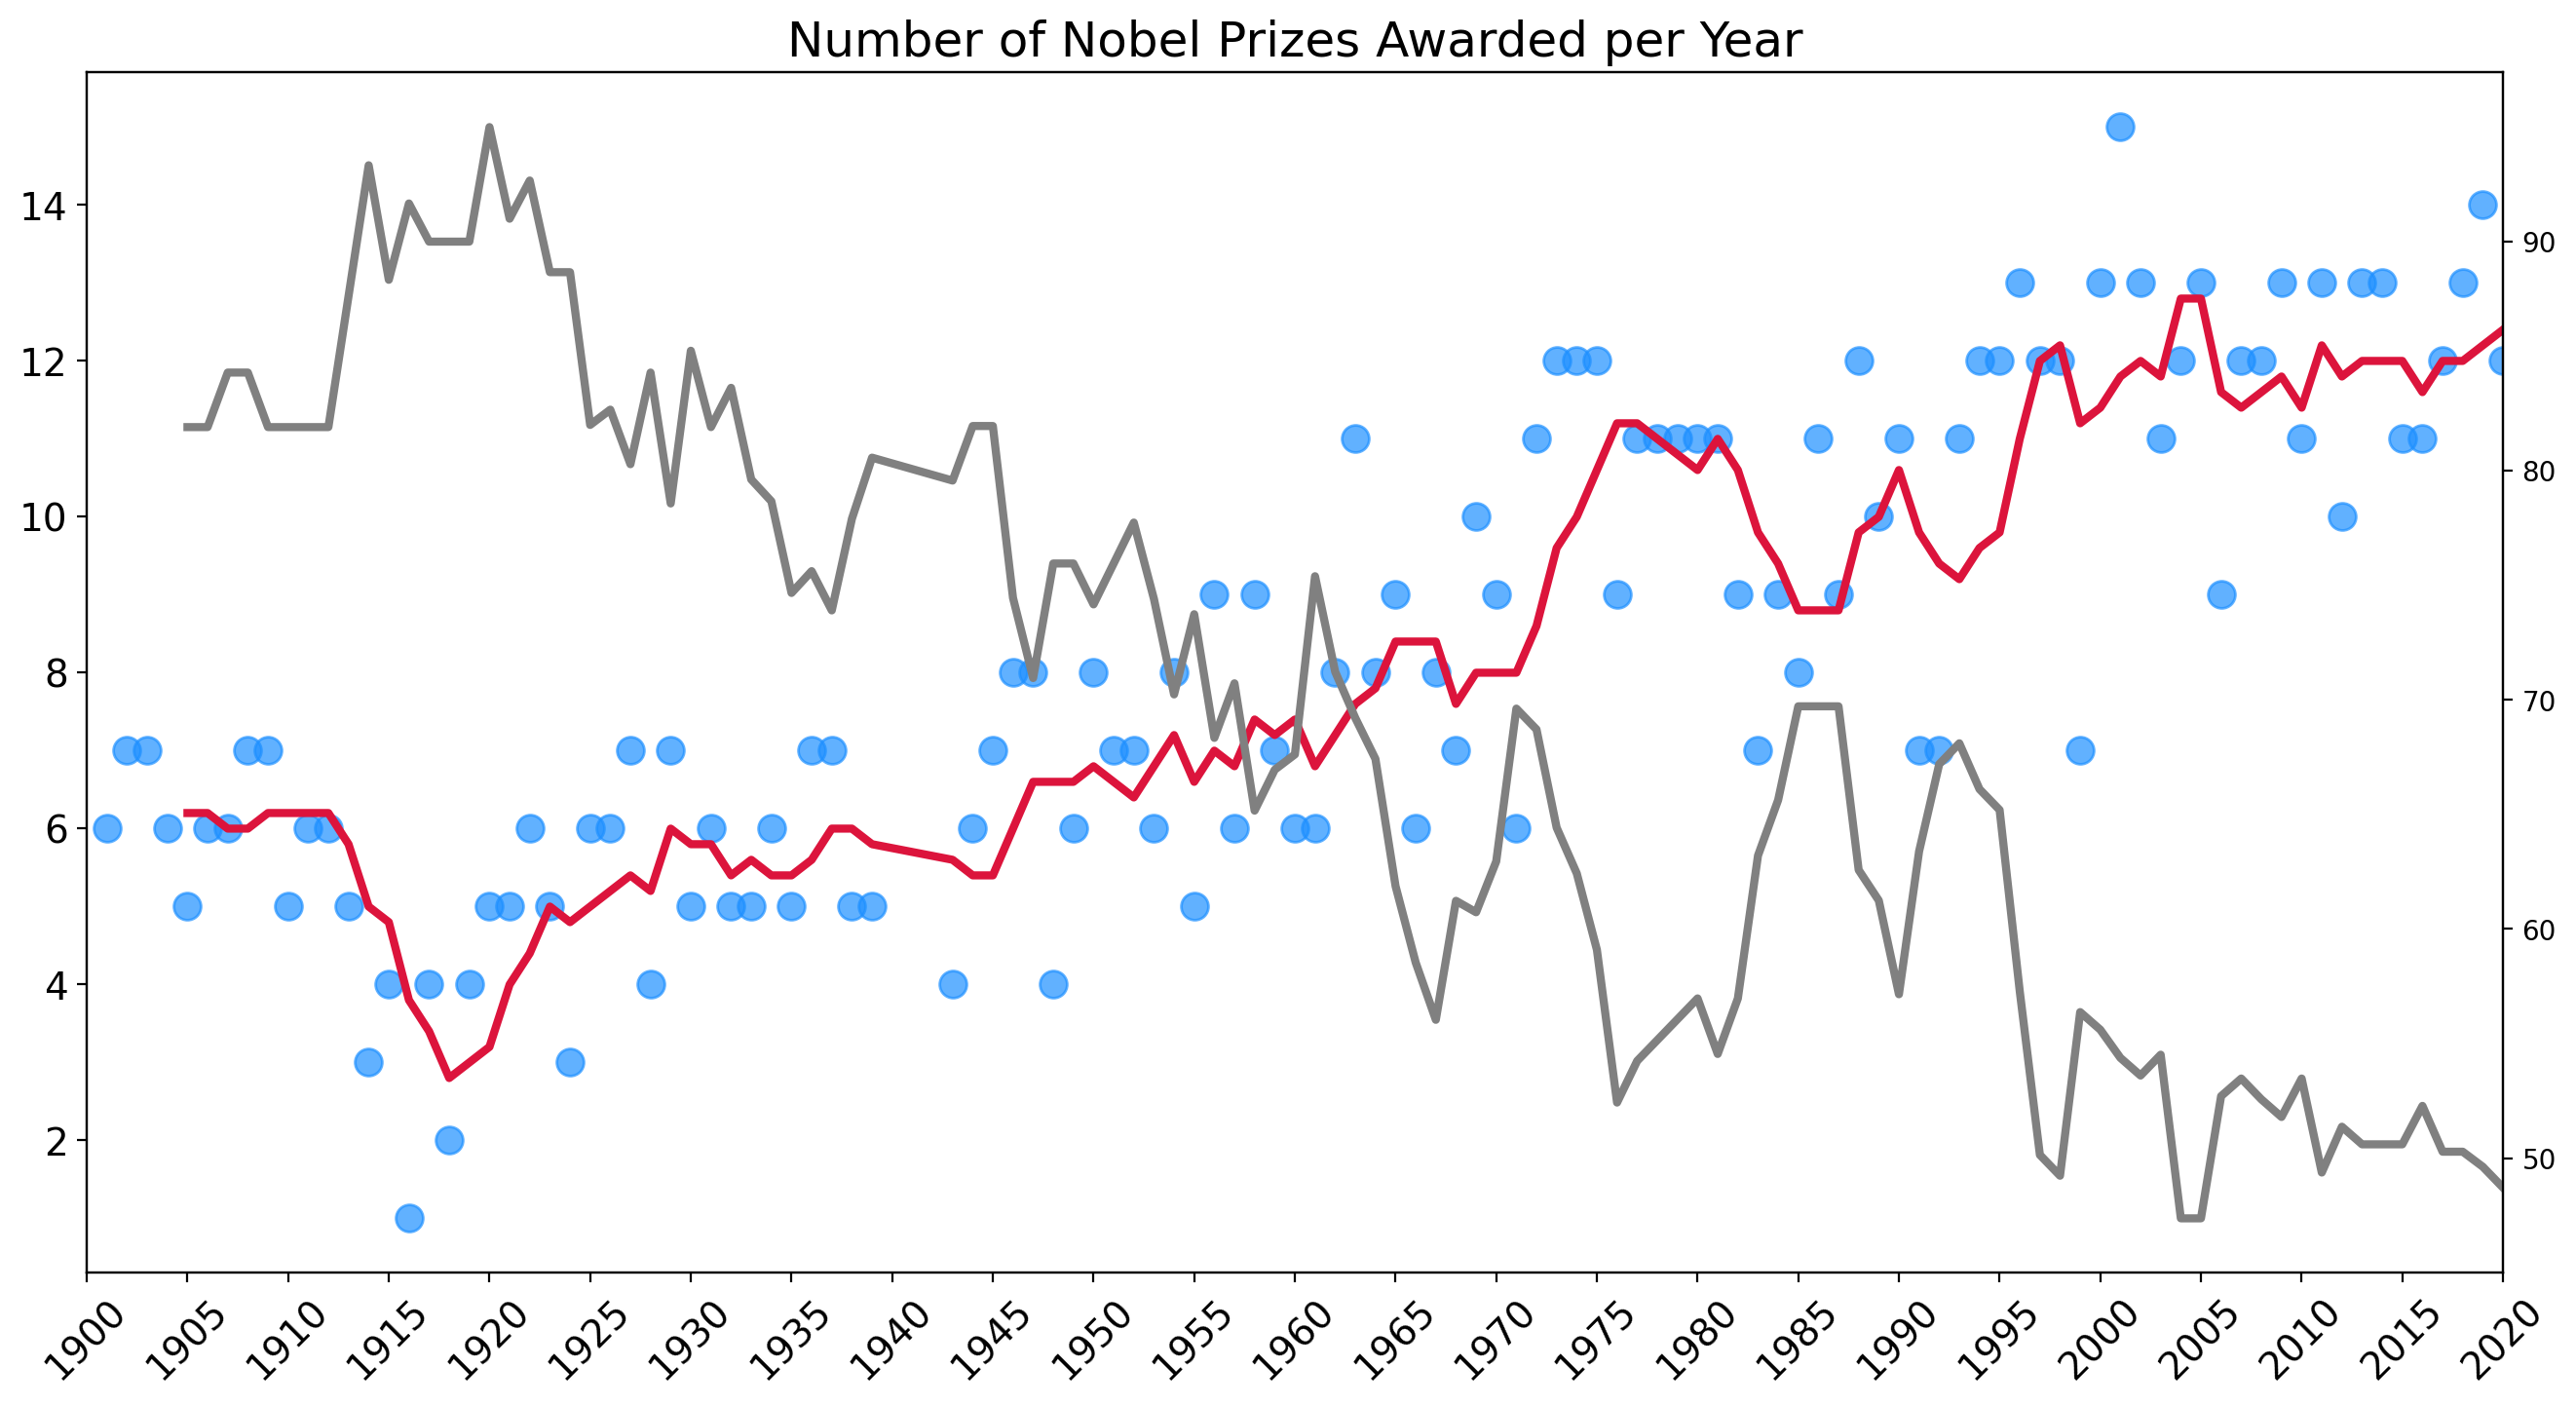

In [43]:
plt.figure(figsize=(16,8), dpi=200)
plt.title('Number of Nobel Prizes Awarded per Year', fontsize=18)
plt.yticks(fontsize=14)
plt.xticks(ticks=np.arange(1900, 2021, step=5),
           fontsize=14,
           rotation=45)

ax1 = plt.gca() # Get the primary axes
ax2 = ax1.twinx() # Create a second y-axis that shares the same x-axis
ax1.set_xlim(1900, 2020)

# Plot individual year prize counts on the primary axis
ax1.scatter(x=prize_per_year.index,
           y=prize_per_year.values,
           c='dodgerblue',
           alpha=0.7,
           s=100,)

# Plot 5-year rolling average of prize counts on the primary axis
ax1.plot(prize_per_year.index,
        moving_average.values,
        c='crimson',
        linewidth=3,)

# Adding prize share rolling average plot on the secondary axis
ax2.plot(prize_per_year.index,
        share_moving_average.values,
        c='grey',
        linewidth=3,)

plt.show()

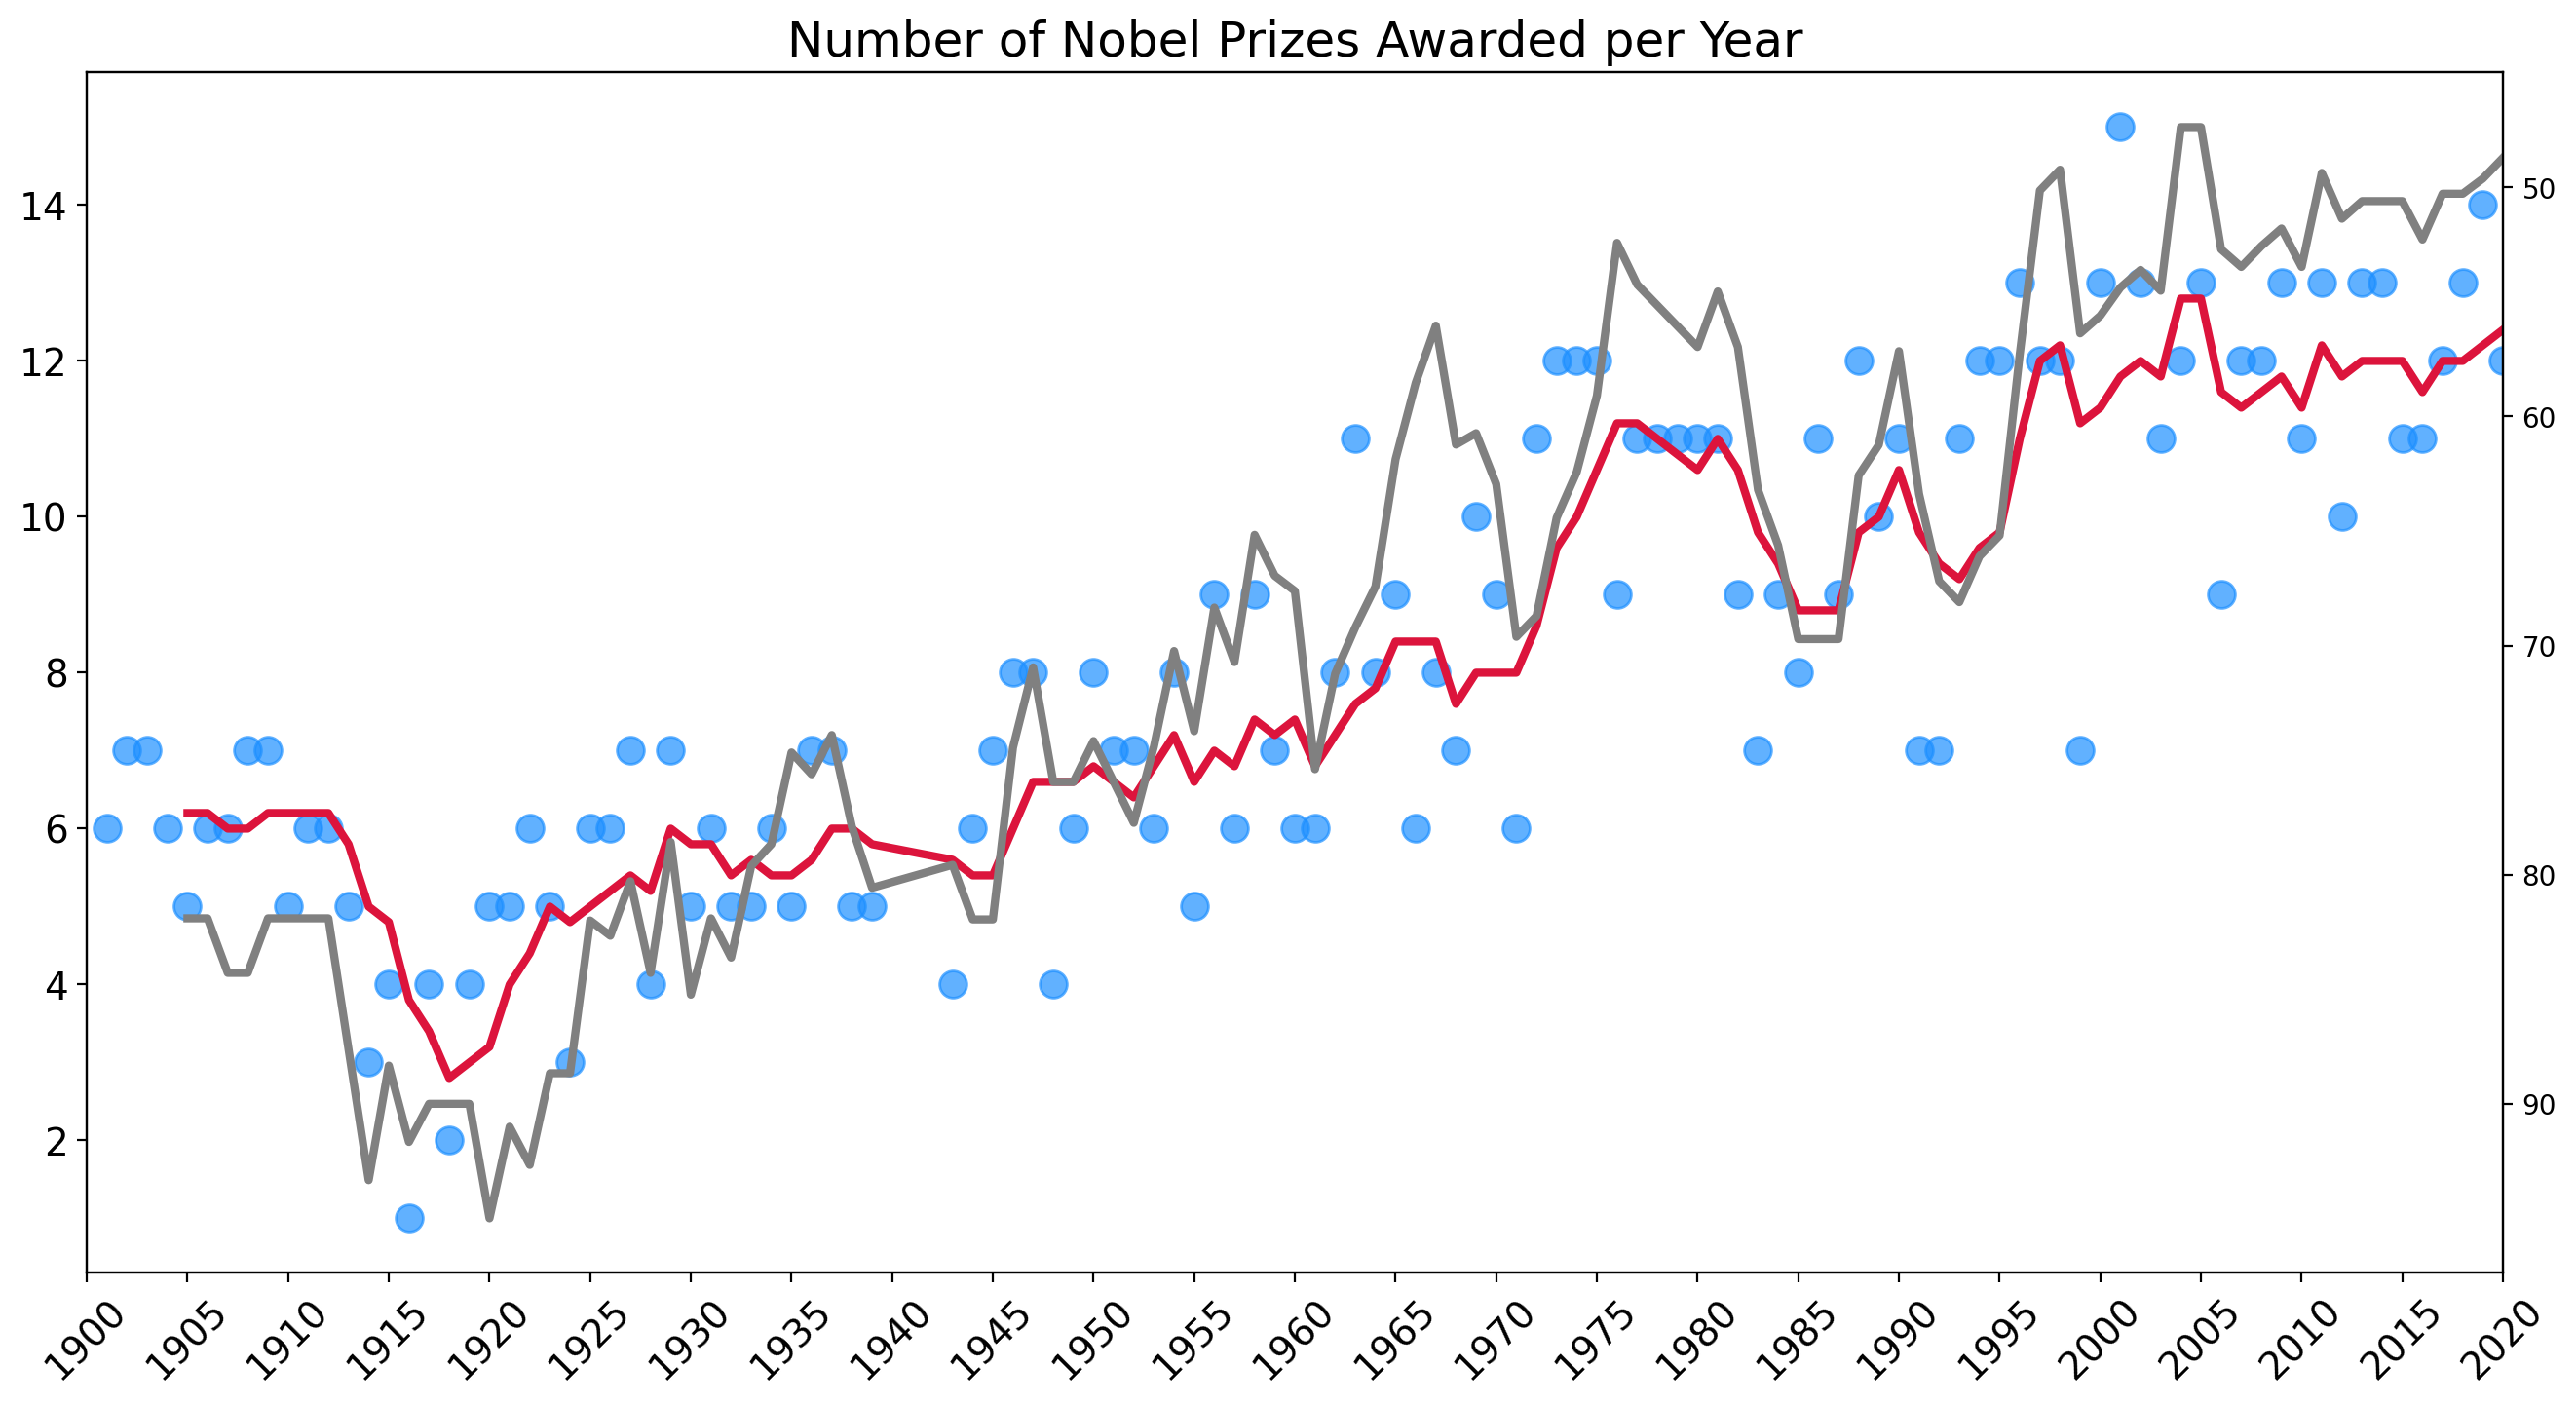

In [44]:
plt.figure(figsize=(16,8), dpi=200)
plt.title('Number of Nobel Prizes Awarded per Year', fontsize=18)
plt.yticks(fontsize=14)
plt.xticks(ticks=np.arange(1900, 2021, step=5),
           fontsize=14,
           rotation=45)

ax1 = plt.gca() # Get the primary axes
ax2 = ax1.twinx() # Create a second y-axis that shares the same x-axis
ax1.set_xlim(1900, 2020)

# Invert the secondary y-axis to show a clearer inverse relationship
ax2.invert_yaxis()

# Plot individual year prize counts on the primary axis
ax1.scatter(x=prize_per_year.index,
           y=prize_per_year.values,
           c='dodgerblue',
           alpha=0.7,
           s=100,)

# Plot 5-year rolling average of prize counts on the primary axis
ax1.plot(prize_per_year.index,
        moving_average.values,
        c='crimson',
        linewidth=3,)

# Plot prize share rolling average on the secondary axis
ax2.plot(prize_per_year.index,
        share_moving_average.values,
        c='grey',
        linewidth=3,)

plt.show()

**Outcome**: What do we see on the chart? Well, there is clearly an upward trend in the number of prizes being given out as more and more prizes are shared. Also, more prizes are being awarded from 1969 onwards because of the addition of the economics category. We also see that very few prizes were awarded during the first and second world wars. Note that instead of there being a zero entry for those years, we instead see the effect of the wards as missing blue dots.

# The Countries with the Most Nobel Prizes

**Challenge**:
* Create a Pandas DataFrame called `top20_countries` that has the two columns. The `prize` column should contain the total number of prizes won.

<img src=https://i.imgur.com/6HM8rfB.png width=350>

* Is it best to use `birth_country`, `birth_country_current` or `organization_country`?
* What are some potential problems when using `birth_country` or any of the others? Which column is the least problematic?
* Then use plotly to create a horizontal bar chart showing the number of prizes won by each country. Here's what you're after:

<img src=https://i.imgur.com/agcJdRS.png width=750>

* What is the ranking for the top 20 countries in terms of the number of prizes?

If you look at the entries in the birth country, you'll see that some countries no longer exist! These include the Soviet Union or Czechoslovakia for example. Hence, using birth_country_current is better, since it has the country name which controls the city where the laureate was born. Now, notice that this does not determine the laureates' nationality since some globetrotting folks gave birth to their future Nobel laureate children while abroad. Also, people's nationalities can change as they emigrate and acquire different citizenship or get married and change citizenship. What this boils down to is that we will have to be clear about the assumptions that we will make in the upcoming analysis.

In [45]:
# Group the DataFrame by 'birth_country_current' and count the number of prizes, then reset the index.
top20_countries = df_data.groupby(by='birth_country_current').agg({'prize': pd.Series.count}).reset_index()

# Sort the countries by the number of prizes in descending order and select the top 20.
top20_countries = top20_countries.sort_values(by='prize', ascending=False).head(20)

# Display the resulting DataFrame.
top20_countries

,birth_country_current,prize
74,United States of America,281
73,United Kingdom,105
26,Germany,84
25,France,57
67,Sweden,29
57,Poland,27
40,Japan,27
61,Russia,26
11,Canada,20
39,Italy,19


In [46]:
h_bar = px.bar(top20_countries,
               x = 'prize',
               y = 'birth_country_current',
               orientation='h', # Horizontal bar chart
               color="prize", # Color bars based on the 'prize' count
               color_continuous_scale="Viridis", # Use Viridis color scale
               title='Top 20 Countries By Number of Prizes')

h_bar.update_layout(xaxis_title='Number of Prizes', yaxis_title='Country')

# Order the bars from largest value at the top to smallest at the bottom
h_bar.update_yaxes(categoryorder="total ascending")

h_bar.show()

**Outcome**: The United States has a massive number of prizes by this measure. The UK and Germany are in second and third place respectively.

# Use a Choropleth Map to Show the Number of Prizes Won by Country

* Create this choropleth map using [the plotly documentation](https://plotly.com/python/choropleth-maps/):

<img src=https://i.imgur.com/s4lqYZH.png>

* Experiment with [plotly's available colours](https://plotly.com/python/builtin-colorscales/). I quite like the sequential colour `matter` on this map.

Hint: You'll need to use a 3 letter country code for each country.


In [47]:
# Group the data by 'birth_country_current' and count the number of prizes, then reset the index.
countries_df = df_data.groupby(by='birth_country_current').agg({'prize': pd.Series.count}).reset_index()

# Sort the DataFrame by the number of prizes in descending order.
countries_df = countries_df.sort_values(by='prize', ascending=False)

# Display the resulting DataFrame.
countries_df

,birth_country_current,prize
74,United States of America,281
73,United Kingdom,105
26,Germany,84
25,France,57
67,Sweden,29
...,...,...
63,Slovakia,1
75,Venezuela,1
76,Vietnam,1
77,Yemen,1


In [48]:
# Select 'ISO' and 'birth_country_current' columns from df_data.
ISO_data = df_data[['ISO', 'birth_country_current']]

# Remove duplicate rows based on 'birth_country_current' to get unique country-ISO pairs.
ISO_data  = ISO_data.drop_duplicates(subset = ['birth_country_current'])

# Display the row for 'United States of America' to verify its ISO code.
ISO_data[ISO_data.birth_country_current == 'United States of America']

# Display the first few rows of the cleaned ISO data.
ISO_data.head()

,ISO,birth_country_current
0,NLD,Netherlands
1,FRA,France
2,POL,Poland
4,CHE,Switzerland
5,DEU,Germany


In [49]:
# Merge the 'countries_df' with 'ISO_data' to add the 'ISO' column based on 'birth_country_current'.
countries_df = countries_df.merge(
    ISO_data[['birth_country_current', 'ISO']],
    on='birth_country_current',
    how='left'
)

In [50]:
# Display the row for 'United States of America' from the merged DataFrame to verify the ISO code.
countries_df[countries_df.birth_country_current == 'United States of America']

,birth_country_current,prize,ISO
0,United States of America,281,USA


In [51]:
fig = px.choropleth(countries_df, locations="ISO", # Use ISO codes for country locations
                    color="prize", # Color countries based on 'prize' count
                    hover_name="birth_country_current", # Show country name on hover
                    color_continuous_scale=px.colors.sequential.matter) # Use 'matter' sequential color scale
fig.show()

# In Which Categories are the Different Countries Winning Prizes?

**Challenge**: See if you can divide up the plotly bar chart you created above to show the which categories made up the total number of prizes. Here's what you're aiming for:

<img src=https://i.imgur.com/iGaIKCL.png>

* In which category are Germany and Japan the weakest compared to the United States?
* In which category does Germany have more prizes than the UK?
* In which categories does France have more prizes than Germany?
* Which category makes up most of Australia's nobel prizes?
* Which category makes up half of the prizes in the Netherlands?
* Does the United States have more prizes in Economics than all of France? What about in Physics or Medicine?


The hard part is preparing the data for this chart!


*Hint*: Take a two-step approach. The first step is grouping the data by country and category. Then you can create a DataFrame that looks something like this:

<img src=https://i.imgur.com/VKjzKa1.png width=450>


Preparing our data to show the breakdown by category and country is challenging. We'll take a two-step approach here. First we count the prizes by category in each country:

In [52]:
# 1. Get the list of top 20 countries by total prizes
# The 'countries_df' DataFrame in the kernel state already contains the total prizes by 'birth_country_current'
top_20_country_names = countries_df.head(20)['birth_country_current'].tolist()

# Group the DataFrame by 'birth_country_current' and 'category', then count the prizes and reset the index.
df_country_prizes_by_category = df_data.groupby(['birth_country_current', 'category']).agg({'prize': pd.Series.count}).reset_index()

# Rename the 'prize' column to 'cat_prize' for clarity.
df_country_prizes_by_category.rename(columns={'prize': 'cat_prize'}, inplace=True) # renaming column name

# Check the DataFrame for 'Australia' to ensure correctness.
df_country_prizes_by_category[df_country_prizes_by_category.birth_country_current == 'Australia'] # checking that the dataframe is correct or not

,birth_country_current,category,cat_prize
4,Australia,Chemistry,1
5,Australia,Medicine,7
6,Australia,Physics,2


In [53]:
# Merge 'df_country_prizes_by_category' with 'countries_df' to add the total prize count per country.
df_country_prizes_by_category = df_country_prizes_by_category.merge(
    countries_df[['birth_country_current', 'prize']],
    on='birth_country_current',
    how='left'
)

Next, we have merged the DataFrame above with the df_country_prizes_by_category DataFrame that we created previously. That way we get the total number of prizes per category in a single column too. This is important since we want to control the order for our bar chart.

In [54]:
# Rename the 'prize' column (from the merge) to 'total_prize' for clarity.
df_country_prizes_by_category.rename(columns={'prize': 'total_prize'}, inplace=True) # renaming column name

# 4. Filter to include only the top 20 countries
df_country_prizes_by_category = df_country_prizes_by_category[df_country_prizes_by_category['birth_country_current'].isin(top_20_country_names)]


# Display a random sample of 7 rows from the filtered DataFrame.
df_country_prizes_by_category.sample(7)

,birth_country_current,category,cat_prize,total_prize
72,Germany,Economics,1,84
142,Norway,Medicine,2,12
83,Hungary,Economics,1,9
185,Switzerland,Medicine,6,19
50,Denmark,Chemistry,1,12
74,Germany,Medicine,18,84
104,Italy,Chemistry,1,19


In [55]:
# Sort the DataFrame by 'total_prize' in descending order to order countries by their overall prize count.
df_country_prizes_by_category.sort_values(by='total_prize', ascending=False, inplace=True)

# Display the first 5 rows of the sorted DataFrame.
df_country_prizes_by_category.head(5)

,birth_country_current,category,cat_prize,total_prize
205,United States of America,Peace,19,281
206,United States of America,Physics,70,281
204,United States of America,Medicine,78,281
203,United States of America,Literature,10,281
202,United States of America,Economics,49,281


In [56]:
horizontal_bar = px.bar(x=df_country_prizes_by_category.cat_prize,
                        y=df_country_prizes_by_category.birth_country_current,
                        orientation='h', # Horizontal bar chart
                        color=df_country_prizes_by_category.category, # Color bars by prize category
                        title="Prizes country winned by each category")

horizontal_bar.update_layout(xaxis_title='Total Prizes',
                          yaxis_title='Country',
                          )
horizontal_bar.update_yaxes(categoryorder='total ascending') # Order y-axis categories by total prize count

horizontal_bar.show()

In [57]:
# Display entries for 'Australia' to verify the category-wise prize distribution.
df_country_prizes_by_category[df_country_prizes_by_category.birth_country_current == 'Australia']

,birth_country_current,category,cat_prize,total_prize
6,Australia,Physics,2,10
4,Australia,Chemistry,1,10
5,Australia,Medicine,7,10


**Outcome** Splitting the country bar chart by category allows us to get a very granular look at the data and answer a whole bunch of questions. For example, we see is that the US has won an incredible proportion of the prizes in the field of Economics. In comparison, Japan and Germany have won very few or no economics prize at all. Also, the US has more prizes in physics or medicine alone than all of France's prizes combined. On the chart, we also see that Germany won more prizes in physics than the UK and that France has won more prizes in peace and literature than Germany, even though Germany has been awarded a higher total number of prizes than France.

### Number of Prizes Won by Each Country Over Time

* When did the United States eclipse every other country in terms of the number of prizes won?
* Which country or countries were leading previously?
* Calculate the cumulative number of prizes won by each country in every year. Again, use the `birth_country_current` of the winner to calculate this.
* Create a [plotly line chart](https://plotly.com/python/line-charts/) where each country is a coloured line.

In [58]:
# Group the DataFrame by 'birth_country_current' and 'year', then count the prizes and reset the index.
df_country_prizes_by_year = df_data.groupby(['birth_country_current', 'year']).agg({'prize': pd.Series.count}).reset_index()
# Sort the DataFrame by 'year' in ascending order.
df_country_prizes_by_year.sort_values(by = ['year'], ascending=True, inplace=True)


df_country_prizes_by_year


,birth_country_current,year,prize
312,Netherlands,1901,1
346,Poland,1901,1
118,France,1901,2
159,Germany,1901,1
440,Switzerland,1901,1
...,...,...,...
244,India,2019,1
221,Germany,2020,1
158,France,2020,1
533,United Kingdom,2020,2


To see how the prize was awarded over time. To do that, we can count the number of prizes by country by year.

In [59]:
# Calculate the running total of prizes for each country over all years.
df_country_prizes_by_year['cumulative prizes each year'] =  df_country_prizes_by_year.groupby('birth_country_current')['prize'].cumsum()

# Display the entries for 'United States of America' to see its cumulative prize count over time.
df_country_prizes_by_year[df_country_prizes_by_year.birth_country_current == 'United States of America']


,birth_country_current,year,prize,cumulative prizes each year
534,United States of America,1906,1,1
535,United States of America,1912,1,2
536,United States of America,1914,1,3
537,United States of America,1919,1,4
538,United States of America,1923,1,5
...,...,...,...,...
618,United States of America,2016,1,259
619,United States of America,2017,6,265
620,United States of America,2018,6,271
621,United States of America,2019,3,274


Then we can create a series that has the cumulative sum for the number of prizes won over the period of each year.

In [60]:
fig = px.line(df_country_prizes_by_year, x="year", y="cumulative prizes each year", color='birth_country_current') # Create a line chart with 'year' on x, 'cumulative prizes' on y, and separate lines by 'birth_country_current'

# The next line shows the plot. It's separated for clarity.
# fig.show()

In [61]:
# Display the Plotly line chart.
fig.show()

**Outcome**: What we see is that the United States really started to take off after the Second World War which decimated Europe. Prior to that, the Nobel prize was pretty much a European affair. Very few laureates were chosen from other parts of the world. This has changed dramatically in the last 40 years or so. There are many more countries represented today than in the early days. Interestingly we also see that the UK and Germany traded places in the 70s and 90s on the total number of prizes won. Sweden being 5th place pretty consistently over many decades is quite interesting too. Perhaps this reflects a little bit of home bias?

# What are the Top Research Organisations?

**Challenge**: Create a bar chart showing the organisations affiliated with the Nobel laureates. It should looks something like this:

<img src=https://i.imgur.com/zZihj2p.png width=600>

* Which organisations make up the top 20?
* How many Nobel prize winners are affiliated with the University of Chicago and Harvard University?

In [62]:
# Filter out rows where 'organization_name' is NaN to focus on laureates with affiliations.
filtered_df_by_org  = df_data.dropna(subset=['organization_name'])

# Display a random sample of 5 rows from the filtered DataFrame.
filtered_df_by_org.sample(5)

,year,category,prize,motivation,prize_share,share_pct,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO
482,1977,Physics,The Nobel Prize in Physics 1977,"""for their fundamental theoretical investigati...",1/3,33.33,Individual,Sir Nevill Francis Mott,1905-09-30,Leeds,United Kingdom,United Kingdom,Male,University of Cambridge,Cambridge,United Kingdom,GBR
657,1995,Medicine,The Nobel Prize in Physiology or Medicine 1995,"""for their discoveries concerning the genetic ...",1/3,33.33,Individual,Eric F. Wieschaus,1947-06-08,"South Bend, IN",United States of America,United States of America,Male,Princeton University,"Princeton, NJ",United States of America,USA
78,1913,Physics,The Nobel Prize in Physics 1913,"""for his investigations on the properties of m...",1/1,100.00,Individual,Heike Kamerlingh Onnes,1853-09-21,Groningen,Netherlands,Netherlands,Male,Leiden University,Leiden,Netherlands,NLD
855,2012,Economics,The Sveriges Riksbank Prize in Economic Scienc...,"""for the theory of stable allocations and the ...",1/2,50.00,Individual,Alvin E. Roth,1951-12-18,"New York, NY",United States of America,United States of America,Male,Harvard University,"Cambridge, MA",United States of America,USA
453,1975,Economics,The Sveriges Riksbank Prize in Economic Scienc...,"""for their contributions to the theory of opti...",1/2,50.00,Individual,Leonid Vitaliyevich Kantorovich,1912-01-19,St. Petersburg,Russian Empire (Russia),Russia,Male,Academy of Sciences,Moscow,Russia,RUS


In [63]:
# Group the filtered DataFrame by 'organization_name' and count the number of prizes for each organization.
filtered_df_by_org = filtered_df_by_org.groupby(by = ['organization_name']).agg({'prize': pd.Series.count}).reset_index()


# Display the entry for 'University of Toronto' to check its prize count.
filtered_df_by_org[filtered_df_by_org.organization_name == 'University of Toronto']

,organization_name,prize
231,University of Toronto,3


In [64]:
filtered_df_by_org.sort_values('prize', ascending=False)

# Create new DataFrame with the top 20 organizations by the number of prizes.
top_20_org_df = filtered_df_by_org.nlargest(20, 'prize')

In [65]:
# Display the first 5 rows of the DataFrame containing the top 20 organizations.
top_20_org_df.head(5)

,organization_name,prize
196,University of California,40
68,Harvard University,29
167,Stanford University,23
117,Massachusetts Institute of Technology (MIT),21
198,University of Chicago,20


In [66]:
hori_bar = px.bar(top_20_org_df,
               x = 'prize',
               y = 'organization_name',
               orientation='h', # Horizontal bar chart
               color="prize", # Color bars based on the 'prize' count
               color_continuous_scale="Viridis", # Use Viridis color scale
               title='Top 20 Research Institutions By Number of Prizes')

hori_bar.update_yaxes(categoryorder='total ascending') # Order y-axis categories by total prize count

hori_bar.show()

# Which Cities Make the Most Discoveries?

Where do major discoveries take place?  

**Challenge**:
* Create another plotly bar chart graphing the top 20 organisation cities of the research institutions associated with a Nobel laureate.
* Where is the number one hotspot for discoveries in the world?
* Which city in Europe has had the most discoveries?

In [173]:
# Count the occurrences of each unique value in the 'organization_city' column and select the top 20.
top20_org_cities = df_data.organization_city.value_counts()[:20]

# Display the resulting Series.
top20_org_cities

,count
organization_city,
"Cambridge, MA",50
"New York, NY",45
Cambridge,31
London,27
Paris,25
"Stanford, CA",24
"Berkeley, CA",21
"Chicago, IL",20
"Princeton, NJ",19


In [174]:
# Sort the top 20 organization cities by their prize count in ascending order.
top20_org_cities.sort_values(ascending=True, inplace=True)

In [175]:
city_bar2 = px.bar(x = top20_org_cities.values,
                  y = top20_org_cities.index,
                  orientation='h', # Horizontal bar chart
                  color=top20_org_cities.values, # Color bars based on the count
                  color_continuous_scale=px.colors.sequential.Plasma, # Use Plasma sequential color scale
                  title='Which Cities Do the Most Research?')

city_bar2.update_layout(xaxis_title='Number of Prizes',
                       yaxis_title='City',
                       coloraxis_showscale=False) # Hide the color scale
city_bar2.show()

**Outcome**: Cambridge Massachusets and New York in the United States lead the pack:



# Where are Nobel Laureates Born? Chart the Laureate Birth Cities

**Challenge**:
* Create a plotly bar chart graphing the top 20 birth cities of Nobel laureates.
* Use a named colour scale called `Plasma` for the chart.
* What percentage of the United States prizes came from Nobel laureates born in New York?
* How many Nobel laureates were born in London, Paris and Vienna?
* Out of the top 5 cities, how many are in the United States?


In [69]:
# Group the DataFrame by 'birth_city' and count the number of prizes, then reset the index.
top20_laureate_birthcity_df = df_data.groupby(by = ['birth_city']).agg({'prize': pd.Series.count}).reset_index()

# Create new DataFrame with the top 20 birth cities by the number of prizes.
top20_laureate_birthcity_df = top20_laureate_birthcity_df.nlargest(20, 'prize')

# Display the resulting DataFrame.
top20_laureate_birthcity_df

,birth_city,prize
382,"New York, NY",53
418,Paris,26
313,London,19
572,Vienna,14
112,"Chicago, IL",12
48,Berlin,11
64,"Boston, MA",8
76,"Brooklyn, NY",8
80,Budapest,8
590,"Washington, DC",8


In [70]:
vertical_bar = px.bar(top20_laureate_birthcity_df,
               x = 'birth_city',
               y = 'prize',
               orientation='v', # Vertical bar chart
               color="prize", # Color bars based on the 'prize' count
               color_continuous_scale="Plasma", # Use Plasma color scale
               title='Top 20 Birht Cities of of Nobel lauretes')

vertical_bar.update_yaxes(categoryorder='total ascending') # Order y-axis categories by total prize count

vertical_bar.show()

**Outcome**: A higher population definitely means that there's a higher chance of a Nobel laureate to be born there. New York, Paris, and London are all very populous. However, Vienna and Budapest are not and still produced many prize winners. That said, much of the ground-breaking research does not take place in big population centres, so the list of birth cities is quite different from the list above. Cambridge Massachusets, Stanford, Berkely and Cambridge (UK) are all the places where many discoveries are made, but they are not the birthplaces of laureates.

# Plotly Sunburst Chart: Combine Country, City, and Organisation

**Challenge**:

* Create a DataFrame that groups the number of prizes by organisation.
* Then use the [plotly documentation to create a sunburst chart](https://plotly.com/python/sunburst-charts/)
* Click around in your chart, what do you notice about Germany and France?


Here's what you're aiming for:

<img src=https://i.imgur.com/cemX4m5.png width=300>



In [71]:
# Display the first 3 rows of the DataFrame to get an overview of the columns.
df_data.head(3)

,year,category,prize,motivation,prize_share,share_pct,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO
0,1901,Chemistry,The Nobel Prize in Chemistry 1901,"""in recognition of the extraordinary services ...",1/1,100.00,Individual,Jacobus Henricus van 't Hoff,1852-08-30,Rotterdam,Netherlands,Netherlands,Male,Berlin University,Berlin,Germany,NLD
1,1901,Literature,The Nobel Prize in Literature 1901,"""in special recognition of his poetic composit...",1/1,100.00,Individual,Sully Prudhomme,1839-03-16,Paris,France,France,Male,NaN,NaN,NaN,FRA
2,1901,Medicine,The Nobel Prize in Physiology or Medicine 1901,"""for his work on serum therapy, especially its...",1/1,100.00,Individual,Emil Adolf von Behring,1854-03-15,Hansdorf (Lawice),Prussia (Poland),Poland,Male,Marburg University,Marburg,Germany,POL


In [72]:
# Group the DataFrame by 'organization_country', 'organization_city', and 'organization_name', then count prizes.
sunburst_chart_df = df_data.groupby(by = ['organization_country', 'organization_city', 'organization_name']).agg({'prize': pd.Series.count}).reset_index()

sunburst_chart_df.rename(columns={'prize': 'organization prize'}, inplace = True) # renaming column name

sunburst_chart_df.sort_values(by = ['organization prize'], ascending= False)



,organization_country,organization_city,organization_name,organization prize
205,United States of America,"Cambridge, MA",Harvard University,29
280,United States of America,"Stanford, CA",Stanford University,23
206,United States of America,"Cambridge, MA",Massachusetts Institute of Technology (MIT),21
209,United States of America,"Chicago, IL",University of Chicago,20
195,United States of America,"Berkeley, CA",University of California,19
...,...,...,...,...
8,Austria,Innsbruck,Innsbruck University,1
6,Austria,Altenberg; Grünau im Almtal,Konrad-Lorenz-Institut der Österreichischen Ak...,1
5,Australia,Weston Creek,Australian National University,1
4,Australia,Nedlands,"NHMRC Helicobacter pylori Research Laboratory,...",1


In [73]:
# Group the sunburst_chart_df by 'organization_country' and sum the 'organization prize' to get total prizes per country.
org_country_total_prize = sunburst_chart_df.groupby('organization_country').agg({'organization prize': pd.Series.count}).reset_index()

org_country_total_prize.rename(columns={'organization prize': 'Overall organization prize'}, inplace = True) # renaming column name

org_country_total_prize.sort_values(by = ['Overall organization prize'], ascending=False).head(5)

,organization_country,Overall organization prize
26,United States of America,104
10,Germany,39
25,United Kingdom,34
9,France,23
16,Japan,14


In [74]:
# Merge 'sunburst_chart_df' with 'org_country_total_prize' to add the overall organization prize count per country.
sunburst_chart_df = sunburst_chart_df.merge(
    org_country_total_prize[['organization_country', 'Overall organization prize']],
    on='organization_country',
    how='left'
)

sunburst_chart_df.tail(5)

,organization_country,organization_city,organization_name,organization prize,Overall organization prize
286,United States of America,"West Lafayette, IN",Purdue University,2,104
287,United States of America,"Wilmington, DE",Du Pont,1,104
288,United States of America,"Woods Hole, MA",Marine Biological Laboratory (MBL),1,104
289,United States of America,"Worcester, MA",University of Massachusetts Medical School,1,104
290,United States of America,"Yorktown Heights, NY",IBM Thomas J. Watson Research Center,1,104


In [75]:
# Get unique country names from 'sunburst_chart_df' and select the top 20 based on 'Overall organization prize'.
top_20_countries = sunburst_chart_df.drop_duplicates(subset = ['organization_country']).nlargest(20, 'Overall organization prize')['organization_country']

print(top_20_countries.shape)
top20_countries.tail()

(20,)


,birth_country_current,prize
20,Denmark,12
2,Australia,10
7,Belgium,9
31,Hungary,9
33,India,9


In [76]:
# Filter 'sunburst_chart_df' to include only the top 20 countries.
sunburst_chart_df = sunburst_chart_df[sunburst_chart_df['organization_country'].isin(top_20_countries)]

sunburst_chart_df.sort_values(by = ['Overall organization prize'], ascending=False)

,organization_country,organization_city,organization_name,organization prize,Overall organization prize
290,United States of America,"Yorktown Heights, NY",IBM Thomas J. Watson Research Center,1,104
289,United States of America,"Worcester, MA",University of Massachusetts Medical School,1,104
288,United States of America,"Woods Hole, MA",Marine Biological Laboratory (MBL),1,104
287,United States of America,"Wilmington, DE",Du Pont,1,104
286,United States of America,"West Lafayette, IN",Purdue University,2,104
...,...,...,...,...,...
124,Norway,Oslo,University of Oslo,3,2
0,Argentina,Buenos Aires,Institute for Biochemical Research,1,2
1,Argentina,Buenos Aires,Instituto de Biologia y Medicina Experimental ...,1,2
21,China,Beijing,China Academy of Traditional Chinese Medicine,1,1


Each country has a number of cities, which contain a number of cities, which in turn contain the research organisations. The sunburst chart is perfect for representing this relationship. It will give us an idea of how geographically concentrated scientific discoveries are!

In [84]:
fig = px.sunburst(sunburst_chart_df, path=['organization_country', 'organization_city', 'organization_name'], values='organization prize',
                  title='Where do Discoveries Take Place?'
                  )

fig.update_layout(xaxis_title='Number of Prizes',
                    yaxis_title='City',
                    coloraxis_showscale=False) # Hide the color scale


fig.show()

**Outcome**: France is a great example of concentration. Practically all the organisations affiliated with Nobel prize winners are in Paris. In contrast, scientific discoveries are much more spread out across Germany. Meanwhile, the UK is dominated by Cambridge and London.

In [78]:
# Get and display the unique values from the 'organization_country' column of the sunburst_chart_df.
sunburst_chart_df['organization_country'].unique()

array(['Argentina', 'Australia', 'Austria', 'Belgium', 'Canada', 'China',
       'Czech Republic', 'Denmark', 'France', 'Germany', 'Israel',
       'Italy', 'Japan', 'Netherlands', 'Norway', 'Russia', 'Sweden',
       'Switzerland', 'United Kingdom', 'United States of America'],
      dtype=object)

# Patterns in the Laureate Age at the Time of the Award

How Old Are the Laureates When the Win the Prize?

**Challenge**: Calculate the age of the laureate in the year of the ceremony and add this as a column called `winning_age` to the `df_data` DataFrame. Hint: you can use [this](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.dt.html) to help you.



In [144]:
# Calculate the 'winning_age' by subtracting the birth year from the prize year.
df_data['winning_age'] = df_data['year'] - df_data['birth_date'].dt.year
# Display the 'full_name', 'year', 'birth_date', and 'winning_age' for the first few rows.
display(df_data[['full_name', 'year', 'birth_date', 'winning_age']].head())

,full_name,year,birth_date,winning_age
0,Jacobus Henricus van 't Hoff,1901,1852-08-30,49.00
1,Sully Prudhomme,1901,1839-03-16,62.00
2,Emil Adolf von Behring,1901,1854-03-15,47.00
3,Frédéric Passy,1901,1822-05-20,79.00
4,Jean Henry Dunant,1901,1828-05-08,73.00


### Who were the oldest and youngest winners?

**Challenge**:
* What are the names of the youngest and oldest Nobel laureate?
* What did they win the prize for?
* What is the average age of a winner?
* 75% of laureates are younger than what age when they receive the prize?
* Use Seaborn to [create histogram](https://seaborn.pydata.org/generated/seaborn.histplot.html) to visualise the distribution of laureate age at the time of winning. Experiment with the number of `bins` to see how the visualisation changes.

In [150]:
# Print the youngest laureate's name, age, and prize details.
print(f"The youngest laureate is {df_data.full_name[df_data.winning_age.idxmin()]} who is {df_data.winning_age.min()} years old when she won {df_data.prize[df_data.winning_age.idxmin()]}")
# Print the oldest laureate's name, age, and prize details.
print(f"The oldest laureate is {df_data.full_name[df_data.winning_age.idxmax()]} who is {df_data.winning_age.max()} years old when he won {df_data.prize[df_data.winning_age.idxmax()]}")

The youngest laureate is Malala Yousafzai who is 17.0 years old when she won The Nobel Peace Prize 2014
The oldest laureate is John Goodenough who is 97.0 years old when he won The Nobel Prize in Chemistry 2019


In [154]:
# Calculate the average winning age and print it, rounded to the nearest integer.
print(f"the average age of winner of nobel prize is {int(round(df_data.winning_age.mean()))}")

the average age of winner of nobel prize is 60


### Descriptive Statistics for the Laureate Age at Time of Award

* Calculate the descriptive statistics for the age at the time of the award.
* Then visualise the distribution in the form of a histogram using [Seaborn's .histplot() function](https://seaborn.pydata.org/generated/seaborn.histplot.html).
* Experiment with the `bin` size. Try 10, 20, 30, and 50.  

In [158]:
# Generate and display descriptive statistics for the 'winning_age' column.
df_data.winning_age.describe()

,winning_age
count,934.00
mean,59.95
std,12.62
min,17.00
25%,51.00
50%,60.00
75%,69.00
max,97.00


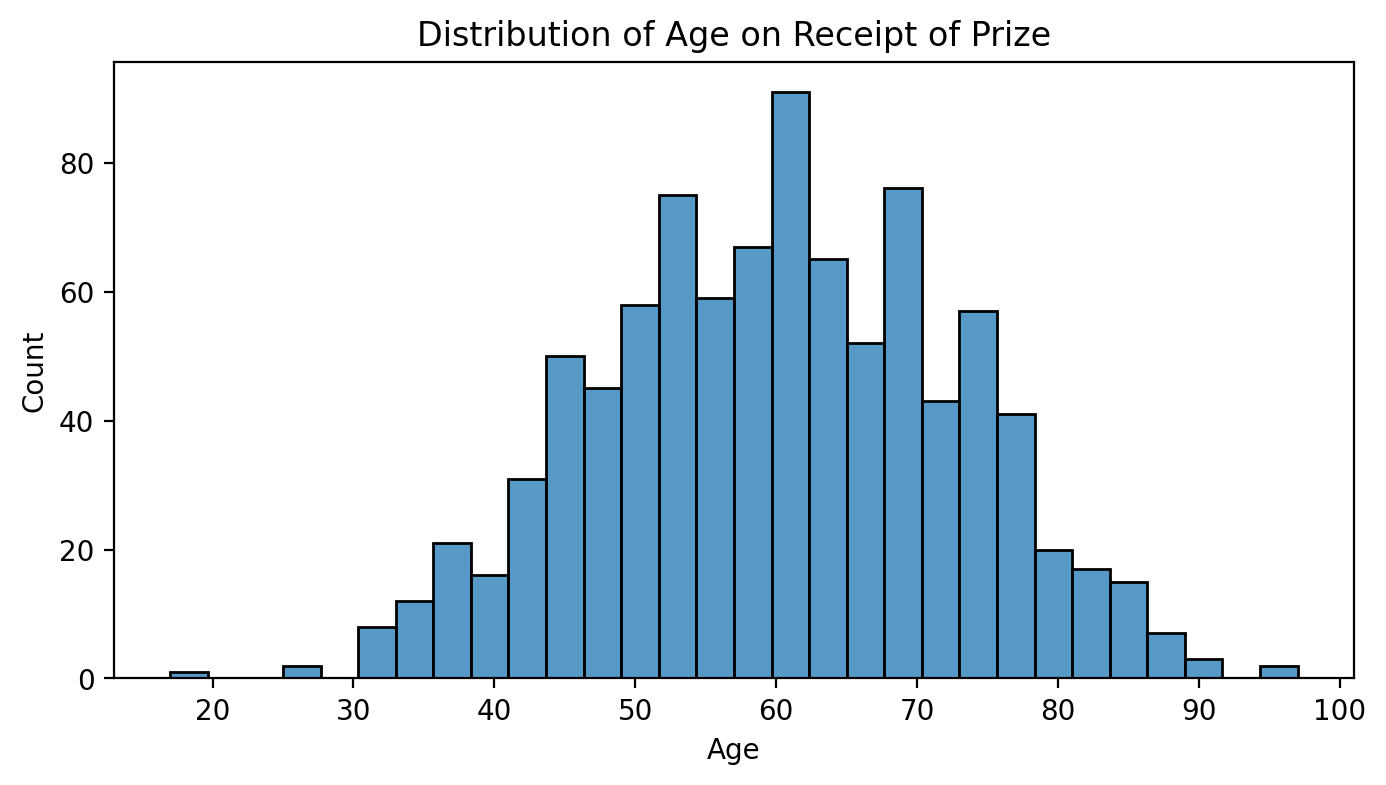

In [165]:
plt.figure(figsize=(8, 4), dpi=200) # Set figure size and resolution
sns.histplot(data=df_data, x="winning_age", bins=30,) # Create a histogram of 'winning_age' with 30 bins
plt.xlabel('Age') # Set x-axis label
plt.title('Distribution of Age on Receipt of Prize') # Set plot title

plt.show()

### Age at Time of Award throughout History

Are Nobel laureates being nominated later in life than before? Have the ages of laureates at the time of the award increased or decreased over time?

**Challenge**

* Use Seaborn to [create a .regplot](https://seaborn.pydata.org/generated/seaborn.regplot.html?highlight=regplot#seaborn.regplot) with a trendline.
* Set the `lowess` parameter to `True` to show a moving average of the linear fit.
* According to the best fit line, how old were Nobel laureates in the years 1900-1940 when they were awarded the prize?
* According to the best fit line, what age would it predict for a Nobel laureate in 2020?


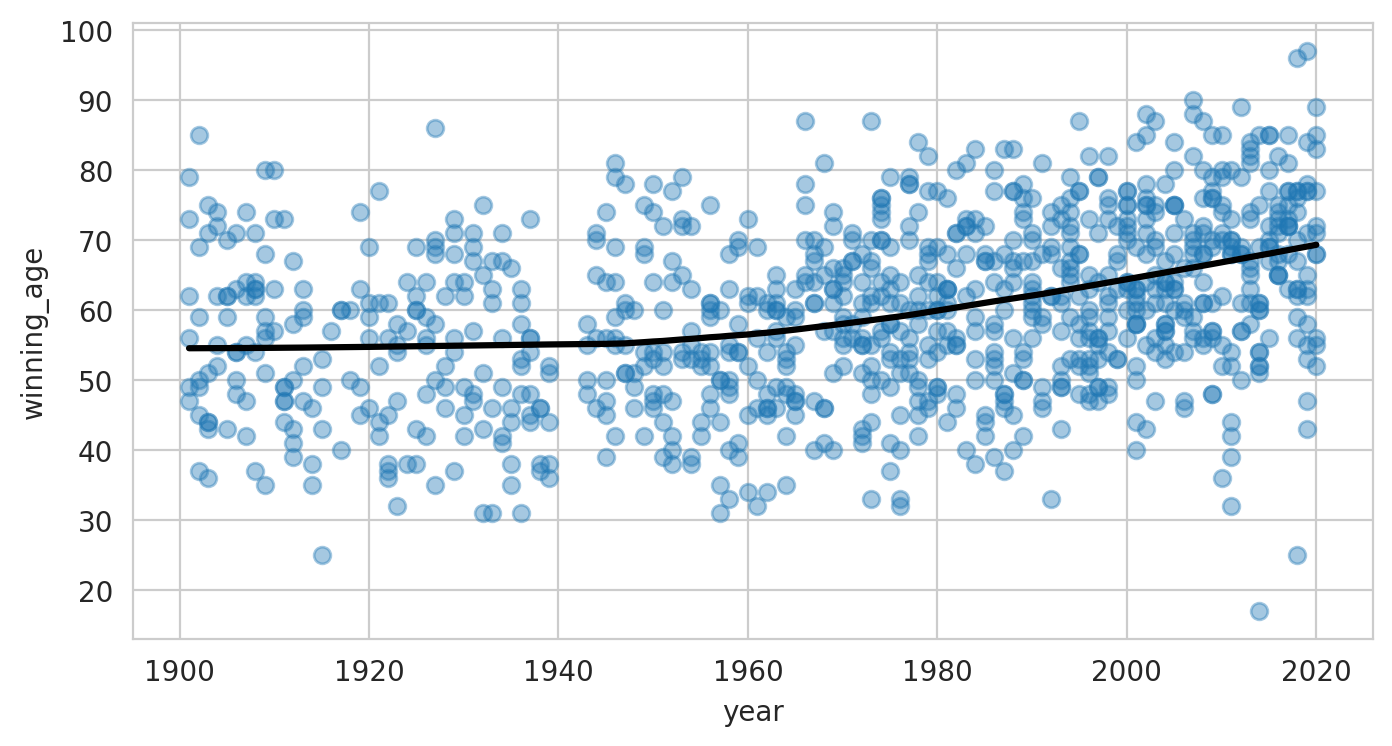

In [166]:
plt.figure(figsize=(8,4), dpi=200) # Set figure size and resolution
with sns.axes_style("whitegrid"): # Apply a white grid style to the plot
    sns.regplot(data=df_data,
                x='year',
                y='winning_age',
                lowess=True, # Use Locally Weighted Scatterplot Smoothing to show a non-linear trend
                scatter_kws = {'alpha': 0.4}, # Adjust transparency of scatter points
                line_kws={'color': 'black'}) # Set the color of the trendline to black

plt.show()

**Outcome**: Using the lowess parameter allows us to plot a local linear regression. This means the best fit line is still linear, but it's more like a moving average which gives us a non-linear shape across the entire series. This is super neat because it clearly shows how the Nobel laureates are getting their award later and later in life. From 1900 to around 1950, the laureates were around 55 years old, but these days they are closer to 70 years old when they get their award! The other thing that we see in the chart is that in the last 10 years the spread has increased. We've had more very young and very old winners. In 1950s/60s winners were between 30 and 80 years old. Lately, that range has widened.

### Winning Age Across the Nobel Prize Categories

How does the age of laureates vary by category?

* Use Seaborn's [`.boxplot()`](https://seaborn.pydata.org/generated/seaborn.boxplot.html?highlight=boxplot#seaborn.boxplot) to show how the mean, quartiles, max, and minimum values vary across categories. Which category has the longest "whiskers"?
* In which prize category are the average winners the oldest?
* In which prize category are the average winners the youngest?

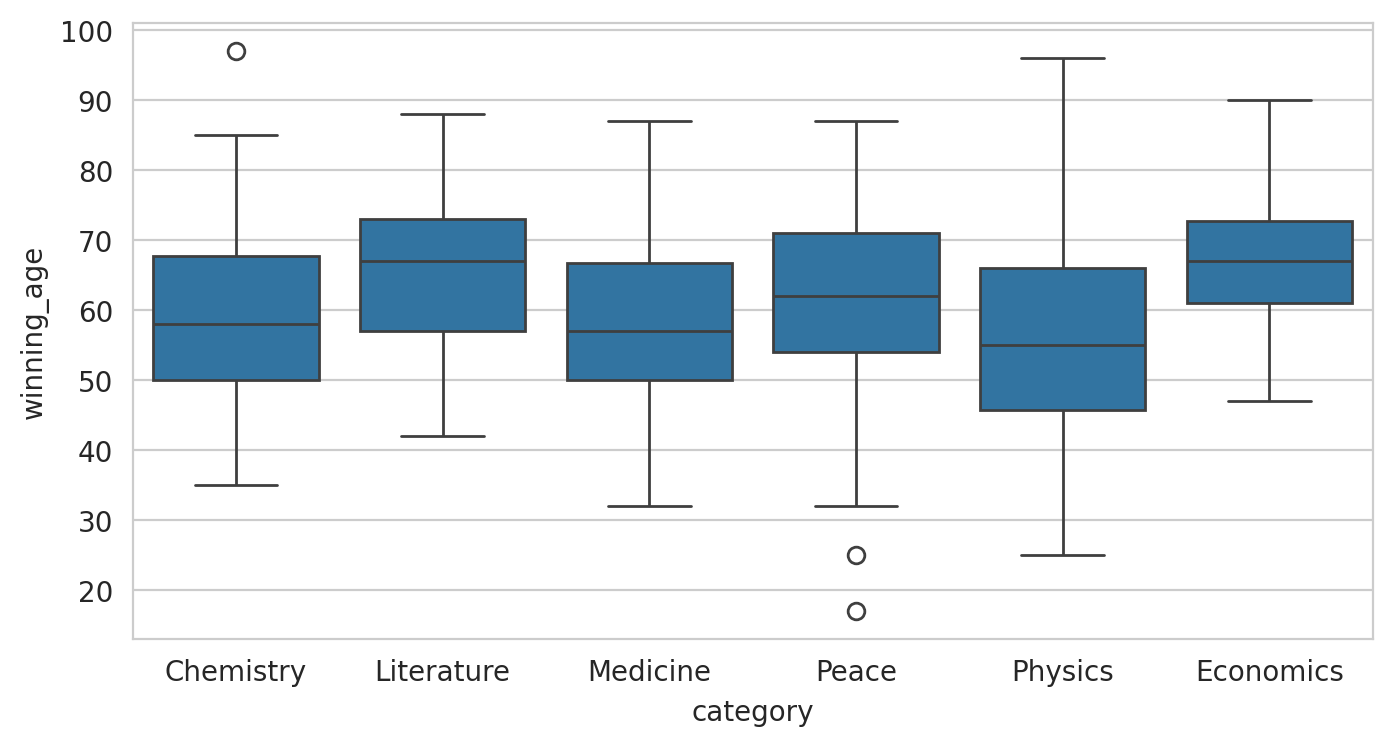

In [169]:
plt.figure(figsize=(8,4), dpi=200) # Set figure size and resolution
with sns.axes_style("whitegrid"): # Apply a white grid style to the plot
    sns.boxplot(data=df_data,
                x='category',
                y='winning_age') # Create a box plot showing winning age distribution across different categories

plt.show()

**Outcome**: The box plot shows us the mean, the quartiles, the maximum and the minimum values. It raises an interesting question: "Are peace prize winners really older than physics laureates?"

**Challenge**
* Now use Seaborn's [`.lmplot()`](https://seaborn.pydata.org/generated/seaborn.lmplot.html?highlight=lmplot#seaborn.lmplot) and the `row` parameter to create 6 separate charts for each prize category. Again set `lowess` to `True`.
* What are the winning age trends in each category?
* Which category has the age trending up and which category has the age trending down?
* Is this `.lmplot()` telling a different story from the `.boxplot()`?
* Create another chart with Seaborn. This time use `.lmplot()` to put all 6 categories on the same chart using the `hue` parameter.


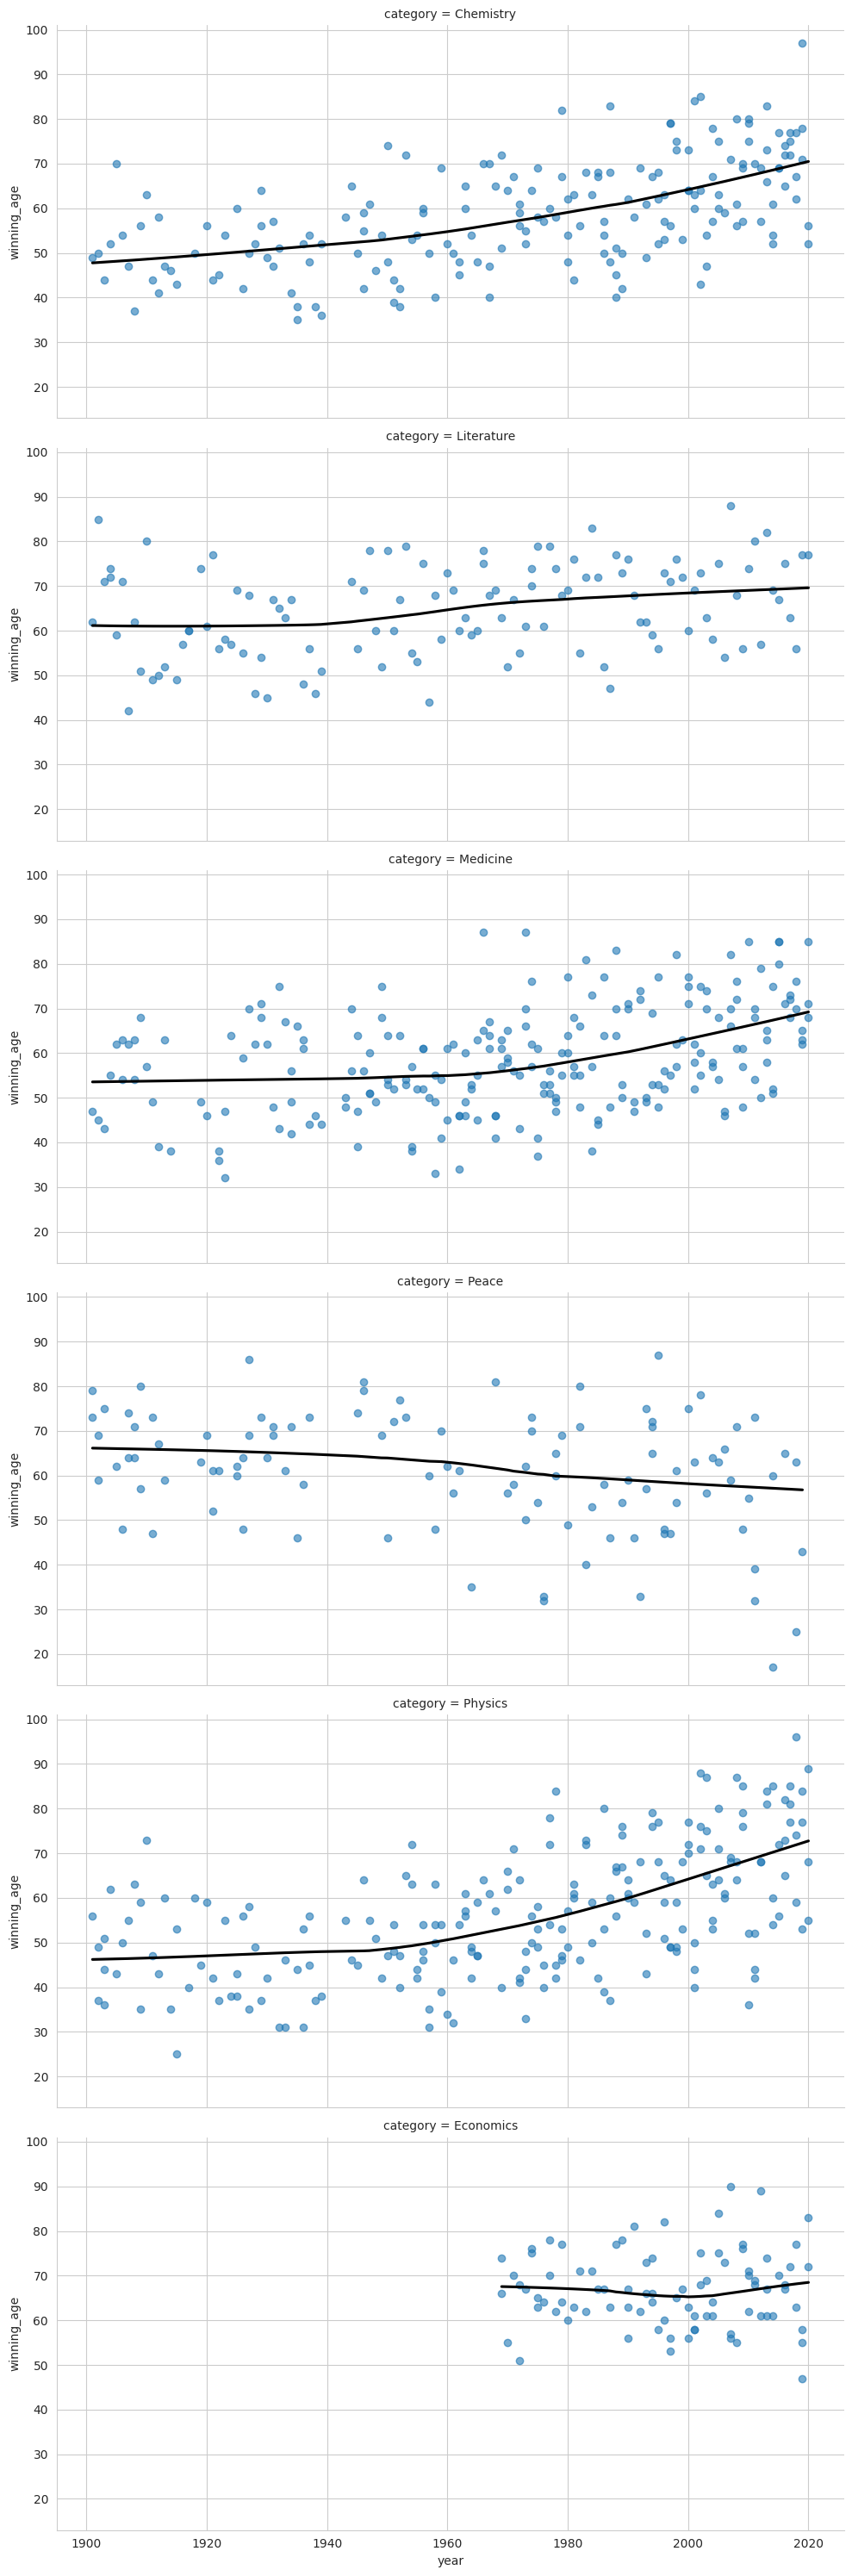

In [170]:
with sns.axes_style('whitegrid'): # Apply a white grid style to the plots
    sns.lmplot(data=df_data,
               x='year', # 'year' on the x-axis
               y='winning_age', # 'winning_age' on the y-axis
               row = 'category', # Create separate plots for each 'category'
               lowess=True, # Use Locally Weighted Scatterplot Smoothing for trendlines
               aspect=2, # Aspect ratio of each facet
               scatter_kws = {'alpha': 0.6}, # Adjust transparency of scatter points
               line_kws = {'color': 'black'},) # Set the color of the trendline to black

plt.show()

**Outcome**: We see that winners in physics, chemistry, and medicine have gotten older over time. The ageing trend is strongest for physics. The average age used to be below 50, but now it's over 70. Economics, the newest category, is much more stable in comparison. The peace prize shows the opposite trend where winners are getting younger! As such, our scatter plots showing the best fit lines over time and our box plot of the entire dataset can tell very different stories!

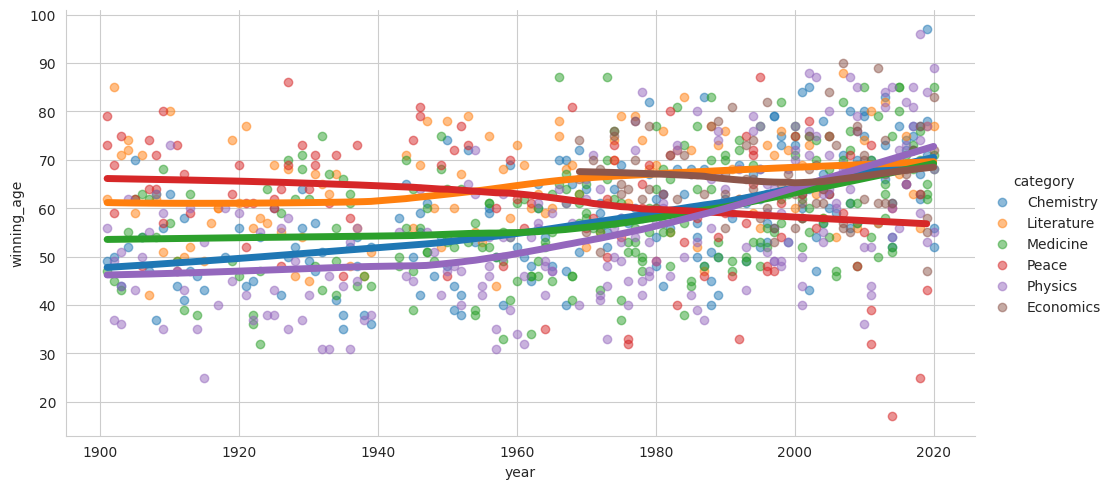

In [172]:
with sns.axes_style("whitegrid"): # Apply a white grid style to the plot
    sns.lmplot(data=df_data,
               x='year', # 'year' on the x-axis
               y='winning_age', # 'winning_age' on the y-axis
               hue='category', # Differentiate lines and scatter points by 'category' using color
               lowess=True, # Use Locally Weighted Scatterplot Smoothing for trendlines
               aspect=2, # Aspect ratio of the plot
               scatter_kws={'alpha': 0.5}, # Adjust transparency of scatter points
               line_kws={'linewidth': 5}) # Set the width of the trendlines

plt.show()

**Outcome**: To combine all these charts into the same chart, we can use the hue parameter